# Regime Switching and MS-GARCH Parameter Analysis

This notebook analyzes regime switching and MS-GARCH parameters to understand:
- How often we are in each regime
- Parameter differences between regimes
- Transition dynamics and regime persistence
- Volatility patterns across regimes

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style for better-looking plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('Libraries imported successfully!')

Libraries imported successfully!


## 2. Load and Explore Data

In [2]:
# Load the data
from pathlib import Path


def _resolve_project_root() -> Path:
    """Find the project root that contains data/output files."""
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd / 'Seminar QF', cwd.parent]

    for candidate in candidates:
        if (candidate / 'data' / 'output' / 'regime_switching_parameters.csv').exists():
            return candidate

    tried = '\n'.join(str(c / 'data' / 'output' / 'regime_switching_parameters.csv') for c in candidates)
    raise FileNotFoundError(f'Could not locate regime_switching_parameters.csv. Tried:\n{tried}')


PROJECT_ROOT = _resolve_project_root()
DATA_OUTPUT = PROJECT_ROOT / 'data' / 'output'
print(f'Using project root: {PROJECT_ROOT}')

rs_params = pd.read_csv(DATA_OUTPUT / 'regime_switching_parameters.csv')
ms_garch = pd.read_csv(DATA_OUTPUT / 'ms_garch_parameters.csv')

# Convert date columns to datetime
rs_params['date'] = pd.to_datetime(rs_params['date'])
ms_garch['date'] = pd.to_datetime(ms_garch['date'])

print('Regime Switching Parameters:')
print(f'Shape: {rs_params.shape}')
print(f'Date range: {rs_params["date"].min()} to {rs_params["date"].max()}')
print(f'Number of companies: {rs_params["gvkey"].nunique()}')
print()
print('MS-GARCH Parameters:')
print(f'Shape: {ms_garch.shape}')
print(f'Date range: {ms_garch["date"].min()} to {ms_garch["date"].max()}')
print(f'Number of companies: {ms_garch["gvkey"].nunique()}')

Using project root: /Users/thomasdeleeuw/Downloads/Seminar-QF/Seminar QF


FileNotFoundError: [Errno 2] No such file or directory: '/Users/thomasdeleeuw/Downloads/Seminar-QF/Seminar QF/data/output/ms_garch_parameters.csv'

In [ ]:
# Display first few rows of each dataset
print('Regime Switching Parameters - First 5 rows:')
display(rs_params.head())

print('\nMS-GARCH Parameters - First 5 rows:')
display(ms_garch.head())

Regime Switching Parameters - First 5 rows:


,gvkey,date,regime_0_mean,regime_1_mean,regime_0_vol,regime_1_vol,regime_0_nu,regime_1_nu,transition_prob_00,transition_prob_01,transition_prob_10,transition_prob_11,regime_0_ar,regime_1_ar
0,14447,2013-02-28,0.000724,-0.000293,0.006400,0.013137,200.0,72.621672,0.955810,0.044190,0.015786,0.984214,0.0,0.0
1,14447,2013-03-29,0.000591,-0.000077,0.006857,0.013547,200.0,71.848150,0.969788,0.030212,0.024474,0.975526,0.0,0.0
2,14447,2013-04-30,0.000605,-0.000049,0.006841,0.013437,200.0,29.302866,0.953591,0.046409,0.028808,0.971192,0.0,0.0
3,14447,2013-05-31,0.000840,0.000173,0.006851,0.012606,200.0,65.235806,0.942458,0.057542,0.034877,0.965123,0.0,0.0
4,14447,2013-06-28,0.000882,-0.000185,0.006820,0.012361,200.0,62.622190,0.944338,0.055662,0.032667,0.967333,0.0,0.0



MS-GARCH Parameters - First 5 rows:


,gvkey,date,omega_0,alpha_0,beta_0,omega_1,alpha_1,beta_1,mu_0,mu_1,...,msgarch_nu_boundary_hits,msgarch_transition_boundary_hits,msgarch_low_confidence,msgarch_blend_weight,adaptive_window_days,window_regime_state,log_likelihood,aic,bic,n_obs
0,14447,2017-01-31,0.000001,0.013701,0.971888,0.000002,0.011467,0.954587,0.000624,-0.000184,...,0,0,True,0.270571,378,Low Vol,-2336.460856,4696.921711,4744.140441,378
1,14447,2017-02-28,0.000018,0.013715,0.762170,0.000045,0.011343,0.776349,0.000411,-0.000006,...,0,0,False,0.261058,378,Low Vol,-2312.459823,4648.919647,4696.138377,378
2,14447,2017-03-31,0.000007,0.013683,0.895384,0.000011,0.011375,0.905794,0.000830,-0.000158,...,0,0,True,0.267161,378,Low Vol,-2291.826630,4607.653260,4654.871990,378
3,14447,2017-04-28,0.000032,0.010011,0.827941,0.000020,0.014991,0.749271,-0.000447,0.000913,...,0,0,False,0.145705,378,Low Vol,-2279.404790,4582.809581,4630.028311,378
4,14447,2017-05-31,0.000026,0.010011,0.852745,0.000016,0.014990,0.779484,-0.000051,0.000849,...,0,0,False,0.139537,378,Low Vol,-2261.348998,4546.697996,4593.916726,378


In [ ]:
# Summary statistics
print('Regime Switching - Summary Statistics:')
display(rs_params.describe())

print('\nMS-GARCH - Summary Statistics:')
display(ms_garch.describe())

Regime Switching - Summary Statistics:


,gvkey,date,regime_0_mean,regime_1_mean,regime_0_vol,regime_1_vol,regime_0_nu,regime_1_nu,transition_prob_00,transition_prob_01,transition_prob_10,transition_prob_11,regime_0_ar,regime_1_ar
count,4842.000000,4842,4842.000000,4842.000000,4842.000000,4842.000000,4842.000000,4842.000000,4842.000000,4842.000000,4842.000000,4842.000000,4842.0,4842.0
mean,97062.439488,2019-02-07 07:01:06.914498,0.000254,-0.010289,0.006387,0.017628,53.119774,27.019154,0.694291,0.305709,0.242813,0.757187,0.0,0.0
min,14447.000000,2012-12-31 00:00:00,-1.029293,-1.028193,0.000006,0.001098,2.100000,2.100000,0.010000,0.001000,0.001000,0.010000,0.0,0.0
25%,17452.000000,2016-02-29 00:00:00,-0.000247,-0.000676,0.001910,0.008906,2.100024,2.100012,0.499998,0.027189,0.018032,0.602791,0.0,0.0
50%,100581.000000,2019-01-31 00:00:00,0.000210,0.000179,0.005027,0.013554,5.358678,3.100864,0.879127,0.120873,0.075369,0.924631,0.0,0.0
75%,132740.000000,2022-01-31 00:00:00,0.001164,0.001028,0.007718,0.022559,61.233237,6.936479,0.972811,0.500002,0.397209,0.981968,0.0,0.0
max,241637.000000,2024-12-31 00:00:00,0.307874,0.329110,0.044222,0.044817,200.000000,200.000000,0.999000,0.990000,0.990000,0.999000,0.0,0.0
std,79567.404809,NaN,0.078771,0.102909,0.007486,0.012029,82.399397,61.668629,0.336428,0.336428,0.309891,0.309891,0.0,0.0



MS-GARCH - Summary Statistics:


,gvkey,date,omega_0,alpha_0,beta_0,omega_1,alpha_1,beta_1,mu_0,mu_1,...,msgarch_persistence_1,msgarch_alpha_boundary_hits,msgarch_nu_boundary_hits,msgarch_transition_boundary_hits,msgarch_blend_weight,adaptive_window_days,log_likelihood,aic,bic,n_obs
count,3264.000000,3264,3.264000e+03,3264.000000,3264.000000,3.264000e+03,3264.000000,3264.000000,3264.000000,3264.000000,...,3264.000000,3264.000000,3264.000000,3264.000000,3264.000000,3264.000000,3264.000000,3264.000000,3264.000000,3264.000000
mean,96970.441176,2021-01-13 17:15:00,7.464408e-05,0.068802,0.721809,5.284758e-04,0.170412,0.651662,-0.004478,-0.005209,...,0.822074,0.215993,0.043811,0.287377,0.023999,254.161765,-1409.443534,2842.887069,2884.161333,254.161765
min,14447.000000,2017-01-31 00:00:00,1.000000e-16,0.010000,0.300000,6.031261e-15,0.010000,0.300000,-13.386118,-13.429851,...,0.600000,0.000000,0.000000,0.000000,0.000000,126.000000,-5297.692532,873.804171,907.839554,126.000000
25%,17452.000000,2019-01-23 06:00:00,7.467425e-07,0.014240,0.614069,1.342578e-05,0.019389,0.528643,-0.000279,-0.000973,...,0.723352,0.000000,0.000000,0.000000,0.000000,126.000000,-1952.859954,1634.722830,1668.758213,126.000000
50%,100330.500000,2021-01-14 12:00:00,4.514136e-06,0.021428,0.705823,8.105150e-05,0.119062,0.664169,0.000200,0.000021,...,0.808000,0.000000,0.000000,0.000000,0.000000,252.000000,-1419.070915,2862.141831,2904.933983,252.000000
75%,132740.000000,2023-01-07 00:00:00,1.772082e-05,0.078453,0.889621,3.129534e-04,0.300000,0.778027,0.000897,0.000666,...,0.943625,0.000000,0.000000,0.000000,0.000000,378.000000,-805.361415,3929.719909,3976.938639,378.000000
max,241637.000000,2024-12-31 00:00:00,5.357114e-03,0.500000,0.984970,1.646677e-02,0.500000,0.984981,0.050000,0.050000,...,0.995000,1.000000,1.000000,2.000000,0.703274,378.000000,-424.902085,10619.385063,10666.603794,378.000000
std,79557.322310,NaN,4.125203e-04,0.095303,0.180447,1.228835e-03,0.162172,0.181270,0.236188,0.237019,...,0.121991,0.411572,0.204706,0.531116,0.070530,104.699928,574.974912,1149.949825,1154.961265,104.699928


## 3. Regime Frequency Analysis


In [ ]:
def calculate_steady_state_probabilities(p00, p11):
    """
    Calculate steady-state probabilities for a 2-state Markov chain.
    
    For a transition matrix:
    P = [[p00, p01],
         [p10, p11]]
    
    Steady state: pi = pi * P
    pi_0 = (1 - p11) / (2 - p00 - p11)
    pi_1 = (1 - p00) / (2 - p00 - p11)
    """
    pi_0 = (1 - p11) / (2 - p00 - p11)
    pi_1 = (1 - p00) / (2 - p00 - p11)
    return pi_0, pi_1

# Calculate steady-state probabilities for regime switching
rs_params['steady_state_regime_0'] = rs_params.apply(
    lambda row: calculate_steady_state_probabilities(row['transition_prob_00'], row['transition_prob_11'])[0],
    axis=1
)
rs_params['steady_state_regime_1'] = rs_params.apply(
    lambda row: calculate_steady_state_probabilities(row['transition_prob_00'], row['transition_prob_11'])[1],
    axis=1
)

# Calculate for MS-GARCH
ms_garch['steady_state_regime_0'] = ms_garch.apply(
    lambda row: calculate_steady_state_probabilities(row['p00'], row['p11'])[0],
    axis=1
)
ms_garch['steady_state_regime_1'] = ms_garch.apply(
    lambda row: calculate_steady_state_probabilities(row['p00'], row['p11'])[1],
    axis=1
)

print('Regime Switching - Average Time in Each Regime:')
print(f'Regime 0: {rs_params["steady_state_regime_0"].mean():.2%}')
print(f'Regime 1: {rs_params["steady_state_regime_1"].mean():.2%}')

print('\nMS-GARCH - Average Time in Each Regime:')
print(f'Regime 0: {ms_garch["steady_state_regime_0"].mean():.2%}')
print(f'Regime 1: {ms_garch["steady_state_regime_1"].mean():.2%}')

Regime Switching - Average Time in Each Regime:
Regime 0: 47.18%
Regime 1: 52.82%

MS-GARCH - Average Time in Each Regime:
Regime 0: 56.84%
Regime 1: 43.16%


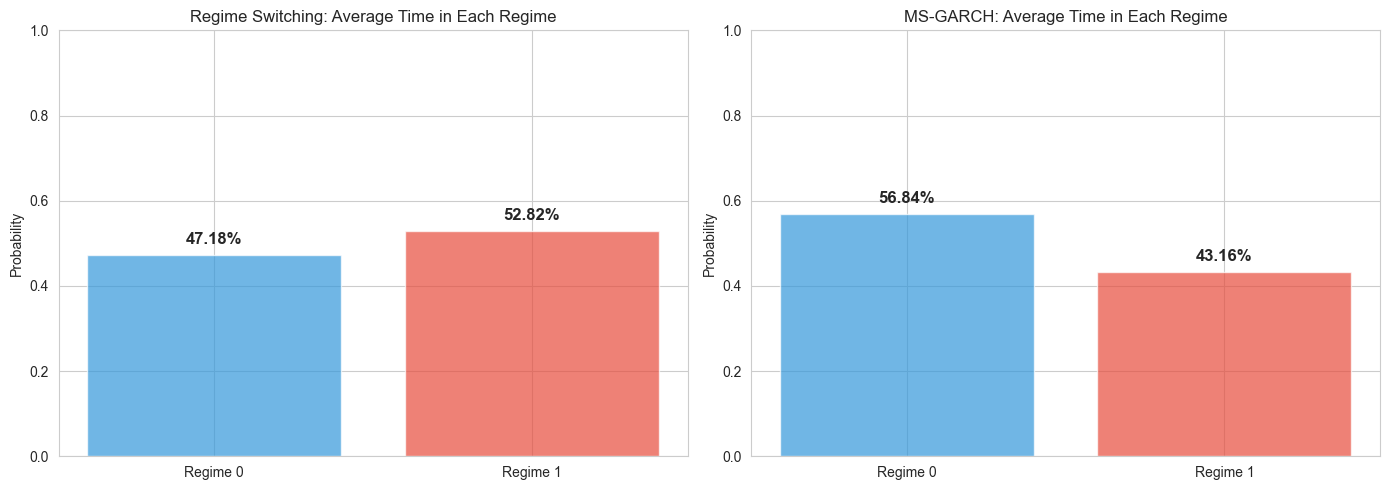

In [ ]:
# Visualize regime frequencies
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Regime Switching
rs_regime_freq = rs_params[['steady_state_regime_0', 'steady_state_regime_1']].mean()
axes[0].bar(['Regime 0', 'Regime 1'], rs_regime_freq, color=['#3498db', '#e74c3c'], alpha=0.7)
axes[0].set_ylabel('Probability')
axes[0].set_title('Regime Switching: Average Time in Each Regime')
axes[0].set_ylim([0, 1])
for i, v in enumerate(rs_regime_freq):
    axes[0].text(i, v + 0.02, f'{v:.2%}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# MS-GARCH
ms_regime_freq = ms_garch[['steady_state_regime_0', 'steady_state_regime_1']].mean()
axes[1].bar(['Regime 0', 'Regime 1'], ms_regime_freq, color=['#3498db', '#e74c3c'], alpha=0.7)
axes[1].set_ylabel('Probability')
axes[1].set_title('MS-GARCH: Average Time in Each Regime')
axes[1].set_ylim([0, 1])
for i, v in enumerate(ms_regime_freq):
    axes[1].text(i, v + 0.02, f'{v:.2%}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

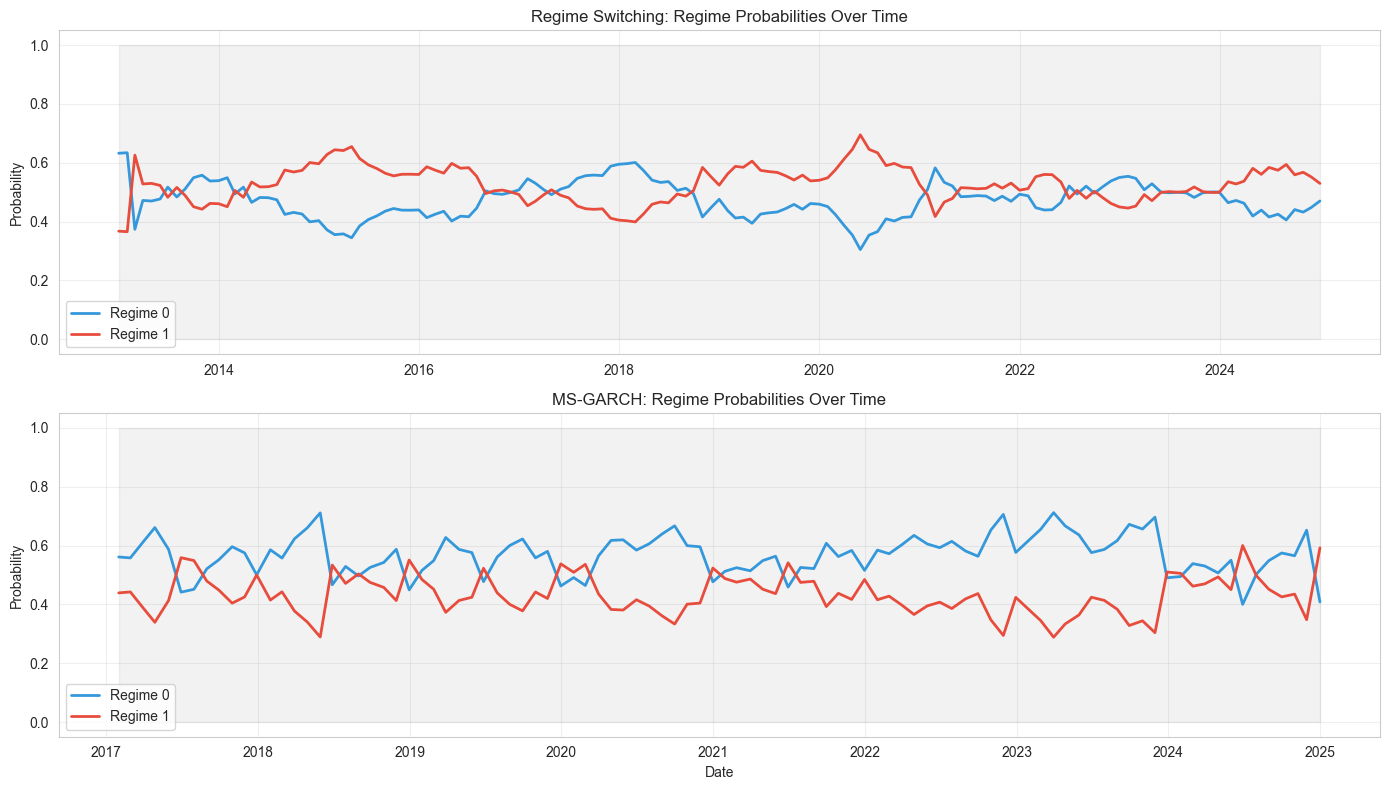

In [ ]:
# Distribution of regime frequencies across time
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Regime Switching over time
rs_time = rs_params.groupby('date')[['steady_state_regime_0', 'steady_state_regime_1']].mean()
axes[0].plot(rs_time.index, rs_time['steady_state_regime_0'], label='Regime 0', color='#3498db', linewidth=2)
axes[0].plot(rs_time.index, rs_time['steady_state_regime_1'], label='Regime 1', color='#e74c3c', linewidth=2)
axes[0].fill_between(rs_time.index, 0, 1, alpha=0.1, color='gray')
axes[0].set_ylabel('Probability')
axes[0].set_title('Regime Switching: Regime Probabilities Over Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MS-GARCH over time
ms_time = ms_garch.groupby('date')[['steady_state_regime_0', 'steady_state_regime_1']].mean()
axes[1].plot(ms_time.index, ms_time['steady_state_regime_0'], label='Regime 0', color='#3498db', linewidth=2)
axes[1].plot(ms_time.index, ms_time['steady_state_regime_1'], label='Regime 1', color='#e74c3c', linewidth=2)
axes[1].fill_between(ms_time.index, 0, 1, alpha=0.1, color='gray')
axes[1].set_ylabel('Probability')
axes[1].set_xlabel('Date')
axes[1].set_title('MS-GARCH: Regime Probabilities Over Time')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Regime Duration Analysis




In [ ]:
# Calculate expected durations
rs_params['duration_regime_0'] = 1 / (1 - rs_params['transition_prob_00'])
rs_params['duration_regime_1'] = 1 / (1 - rs_params['transition_prob_11'])

ms_garch['duration_regime_0'] = 1 / (1 - ms_garch['p00'])
ms_garch['duration_regime_1'] = 1 / (1 - ms_garch['p11'])

print('Regime Switching - Expected Duration (in periods):')
print(f'Regime 0: {rs_params["duration_regime_0"].mean():.2f} ± {rs_params["duration_regime_0"].std():.2f}')
print(f'Regime 1: {rs_params["duration_regime_1"].mean():.2f} ± {rs_params["duration_regime_1"].std():.2f}')

print('\nMS-GARCH - Expected Duration (in periods):')
print(f'Regime 0: {ms_garch["duration_regime_0"].mean():.2f} ± {ms_garch["duration_regime_0"].std():.2f}')
print(f'Regime 1: {ms_garch["duration_regime_1"].mean():.2f} ± {ms_garch["duration_regime_1"].std():.2f}')

Regime Switching - Expected Duration (in periods):
Regime 0: 58.98 ± 164.56
Regime 1: 125.25 ± 278.06

MS-GARCH - Expected Duration (in periods):
Regime 0: 44.48 ± 58.39
Regime 1: 29.98 ± 44.68


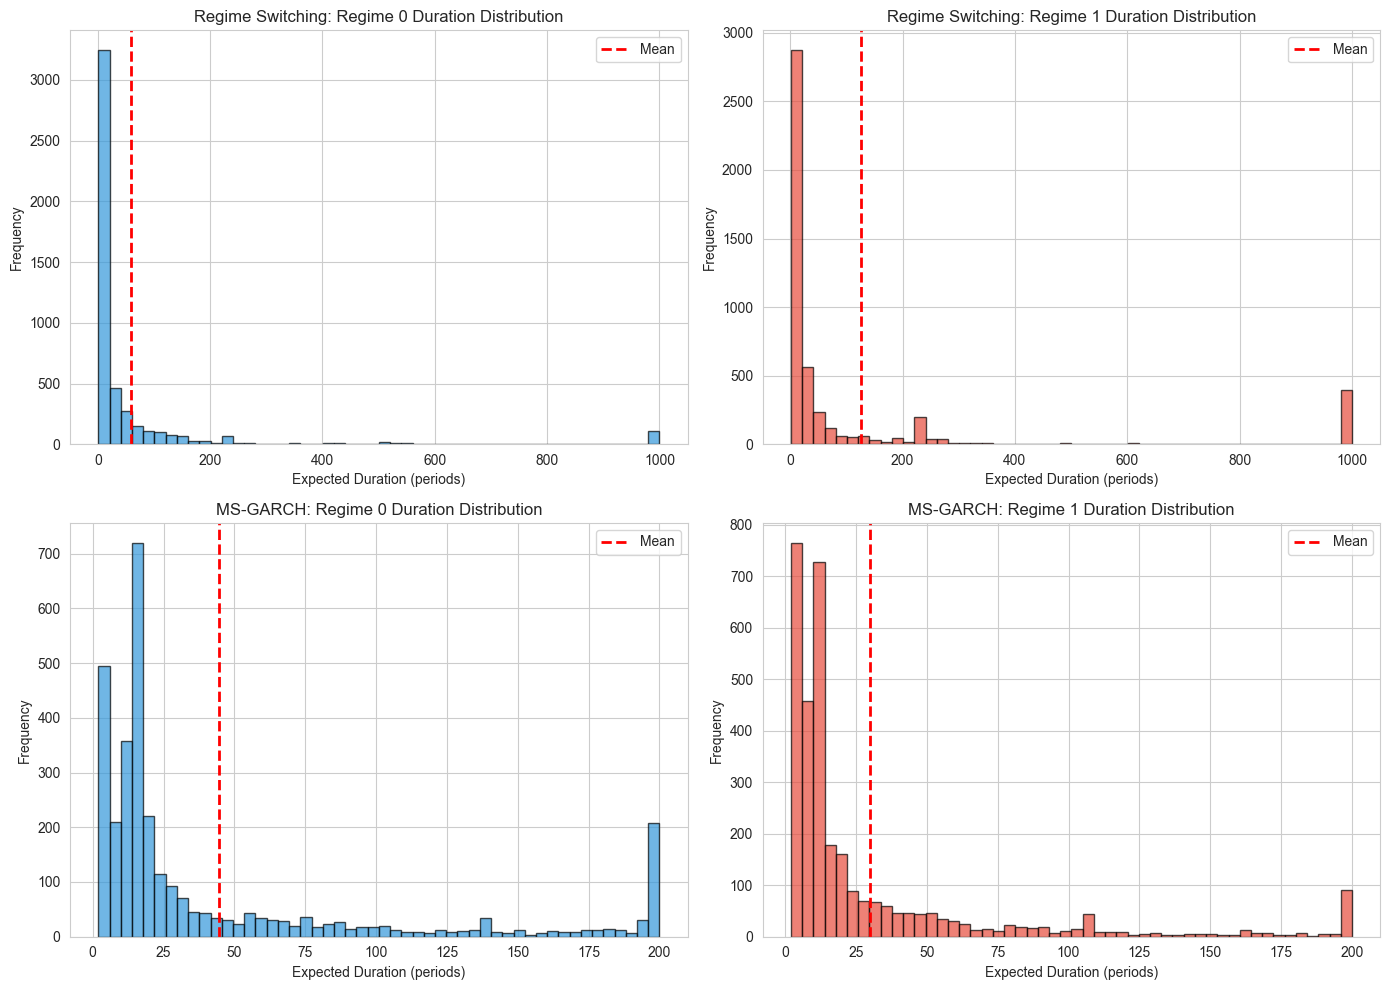


Note: Durations capped at 1000 periods for visualization
Infinite/extreme durations filtered:
  RS Regime 0: 0
  RS Regime 1: 0
  MS-GARCH Regime 0: 0
  MS-GARCH Regime 1: 0


In [ ]:
# Visualize duration distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Filter out infinite values and cap durations for better visualization
def filter_duration(series, max_duration=1000):
    """Filter out infinite values and cap at max_duration for visualization"""
    return series.replace([np.inf, -np.inf], np.nan).clip(upper=max_duration)

# Regime Switching - Regime 0
rs_dur_0_filtered = filter_duration(rs_params['duration_regime_0'])
axes[0, 0].hist(rs_dur_0_filtered.dropna(), bins=50, color='#3498db', alpha=0.7, edgecolor='black')
axes[0, 0].axvline(rs_dur_0_filtered.mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[0, 0].set_xlabel('Expected Duration (periods)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Regime Switching: Regime 0 Duration Distribution')
axes[0, 0].legend()

# Regime Switching - Regime 1
rs_dur_1_filtered = filter_duration(rs_params['duration_regime_1'])
axes[0, 1].hist(rs_dur_1_filtered.dropna(), bins=50, color='#e74c3c', alpha=0.7, edgecolor='black')
axes[0, 1].axvline(rs_dur_1_filtered.mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[0, 1].set_xlabel('Expected Duration (periods)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Regime Switching: Regime 1 Duration Distribution')
axes[0, 1].legend()

# MS-GARCH - Regime 0
ms_dur_0_filtered = filter_duration(ms_garch['duration_regime_0'])
axes[1, 0].hist(ms_dur_0_filtered.dropna(), bins=50, color='#3498db', alpha=0.7, edgecolor='black')
axes[1, 0].axvline(ms_dur_0_filtered.mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[1, 0].set_xlabel('Expected Duration (periods)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('MS-GARCH: Regime 0 Duration Distribution')
axes[1, 0].legend()

# MS-GARCH - Regime 1
ms_dur_1_filtered = filter_duration(ms_garch['duration_regime_1'])
axes[1, 1].hist(ms_dur_1_filtered.dropna(), bins=50, color='#e74c3c', alpha=0.7, edgecolor='black')
axes[1, 1].axvline(ms_dur_1_filtered.mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[1, 1].set_xlabel('Expected Duration (periods)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('MS-GARCH: Regime 1 Duration Distribution')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Print info about filtered values
print(f"\nNote: Durations capped at 1000 periods for visualization")
print(f"Infinite/extreme durations filtered:")
print(f"  RS Regime 0: {rs_params['duration_regime_0'].isna().sum() + (rs_params['duration_regime_0'] > 1000).sum()}")
print(f"  RS Regime 1: {rs_params['duration_regime_1'].isna().sum() + (rs_params['duration_regime_1'] > 1000).sum()}")
print(f"  MS-GARCH Regime 0: {ms_garch['duration_regime_0'].isna().sum() + (ms_garch['duration_regime_0'] > 1000).sum()}")
print(f"  MS-GARCH Regime 1: {ms_garch['duration_regime_1'].isna().sum() + (ms_garch['duration_regime_1'] > 1000).sum()}")

## 5. Parameter Comparison Between Regimes

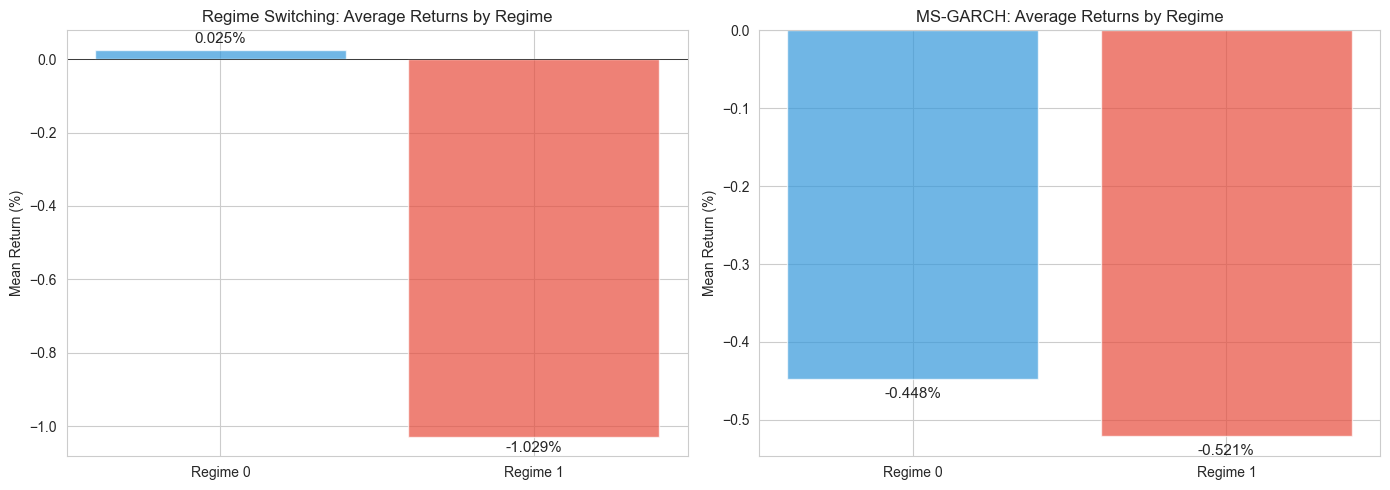

In [ ]:
# Compare mean returns between regimes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Regime Switching
rs_means = rs_params[['regime_0_mean', 'regime_1_mean']].mean() * 100  # Convert to percentage
axes[0].bar(['Regime 0', 'Regime 1'], rs_means, color=['#3498db', '#e74c3c'], alpha=0.7)
axes[0].set_ylabel('Mean Return (%)')
axes[0].set_title('Regime Switching: Average Returns by Regime')
axes[0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
for i, v in enumerate(rs_means):
    axes[0].text(i, v + (0.01 if v > 0 else -0.01), f'{v:.3f}%', ha='center', va='bottom' if v > 0 else 'top', fontsize=11)

# MS-GARCH
ms_means = ms_garch[['mu_0', 'mu_1']].mean() * 100
axes[1].bar(['Regime 0', 'Regime 1'], ms_means, color=['#3498db', '#e74c3c'], alpha=0.7)
axes[1].set_ylabel('Mean Return (%)')
axes[1].set_title('MS-GARCH: Average Returns by Regime')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
for i, v in enumerate(ms_means):
    axes[1].text(i, v + (0.01 if v > 0 else -0.01), f'{v:.3f}%', ha='center', va='bottom' if v > 0 else 'top', fontsize=11)

plt.tight_layout()
plt.show()

In [ ]:
# Detailed parameter comparison table
print('='*80)
print('REGIME SWITCHING MODEL - PARAMETER COMPARISON')
print('='*80)
comparison_rs = pd.DataFrame({
    'Parameter': ['Mean Return', 'Volatility', 'Degrees of Freedom (nu)'],
    'Regime 0': [
        f"{rs_params['regime_0_mean'].mean()*100:.4f}%",
        f"{rs_params['regime_0_vol'].mean()*100:.4f}%",
        f"{rs_params['regime_0_nu'].mean():.2f}"
    ],
    'Regime 1': [
        f"{rs_params['regime_1_mean'].mean()*100:.4f}%",
        f"{rs_params['regime_1_vol'].mean()*100:.4f}%",
        f"{rs_params['regime_1_nu'].mean():.2f}"
    ],
    'Difference': [
        f"{(rs_params['regime_1_mean'].mean() - rs_params['regime_0_mean'].mean())*100:.4f}%",
        f"{(rs_params['regime_1_vol'].mean() - rs_params['regime_0_vol'].mean())*100:.4f}%",
        f"{rs_params['regime_1_nu'].mean() - rs_params['regime_0_nu'].mean():.2f}"
    ]
})
display(comparison_rs)

print('\n' + '='*80)
print('MS-GARCH MODEL - PARAMETER COMPARISON')
print('='*80)
comparison_ms = pd.DataFrame({
    'Parameter': ['Mean Return', 'Degrees of Freedom (nu)', 'Omega', 'Alpha', 'Beta'],
    'Regime 0': [
        f"{ms_garch['mu_0'].mean()*100:.4f}%",
        f"{ms_garch['nu_0'].mean():.2f}",
        f"{ms_garch['omega_0'].mean():.6f}",
        f"{ms_garch['alpha_0'].mean():.6f}",
        f"{ms_garch['beta_0'].mean():.6f}"
    ],
    'Regime 1': [
        f"{ms_garch['mu_1'].mean()*100:.4f}%",
        f"{ms_garch['nu_1'].mean():.2f}",
        f"{ms_garch['omega_1'].mean():.6f}",
        f"{ms_garch['alpha_1'].mean():.6f}",
        f"{ms_garch['beta_1'].mean():.6f}"
    ],
    'Ratio (R1/R0)': [
        f"{ms_garch['mu_1'].mean() / ms_garch['mu_0'].mean() if ms_garch['mu_0'].mean() != 0 else np.nan:.2f}",
        f"{ms_garch['nu_1'].mean() / ms_garch['nu_0'].mean():.2f}",
        f"{ms_garch['omega_1'].mean() / ms_garch['omega_0'].mean() if ms_garch['omega_0'].mean() != 0 else np.nan:.2f}",
        f"{ms_garch['alpha_1'].mean() / ms_garch['alpha_0'].mean() if ms_garch['alpha_0'].mean() != 0 else np.nan:.2f}",
        f"{ms_garch['beta_1'].mean() / ms_garch['beta_0'].mean():.2f}"
    ]
})
display(comparison_ms)

REGIME SWITCHING MODEL - PARAMETER COMPARISON


,Parameter,Regime 0,Regime 1,Difference
0,Mean Return,0.0254%,-1.0289%,-1.0543%
1,Volatility,0.6387%,1.7628%,1.1241%
2,Degrees of Freedom (nu),53.12,27.02,-26.10



MS-GARCH MODEL - PARAMETER COMPARISON


,Parameter,Regime 0,Regime 1,Ratio (R1/R0)
0,Mean Return,-0.4478%,-0.5209%,1.16
1,Degrees of Freedom (nu),16.07,4.36,0.27
2,Omega,0.000075,0.000528,7.08
3,Alpha,0.068802,0.170412,2.48
4,Beta,0.721809,0.651662,0.90


## 6. Volatility Analysis by Regime

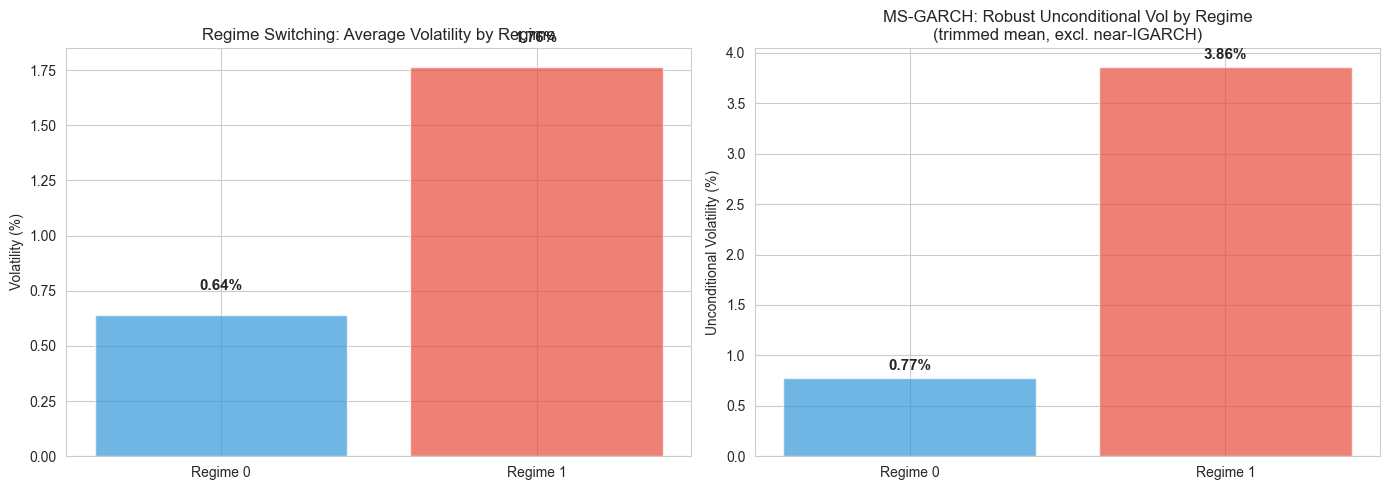

Regime Switching:  Vol Ratio (R1/R0) = 2.76x
MS-GARCH (naive):  Vol Ratio (R1/R0) = 5.00x  ⚠️ inflated by near-IGARCH rows
MS-GARCH (robust): Vol Ratio (R1/R0) = 5.00x

Regime 0: 0 of 3264 rows (0.0%) have persistence ≥ 0.999 → uncond vol set to NaN
Regime 1: 0 of 3264 rows (0.0%) have persistence ≥ 0.999 → uncond vol set to NaN


In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Regime Switching — these are stored directly, no inflation issue
rs_vols = rs_params[['regime_0_vol', 'regime_1_vol']].mean() * 100
axes[0].bar(['Regime 0', 'Regime 1'], rs_vols, color=['#3498db', '#e74c3c'], alpha=0.7)
axes[0].set_ylabel('Volatility (%)')
axes[0].set_title('Regime Switching: Average Volatility by Regime')
for i, v in enumerate(rs_vols):
    axes[0].text(i, v + 0.1, f'{v:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

# MS-GARCH — Robust unconditional volatility
# Step 1: compute raw persistence and uncond_vol
ms_garch['persist_0'] = ms_garch['alpha_0'] + ms_garch['beta_0']
ms_garch['persist_1'] = ms_garch['alpha_1'] + ms_garch['beta_1']

# Step 2: compute unconditional vol, but mark near-IGARCH as NaN
for r in [0, 1]:
    p_col = f'persist_{r}'
    denom = 1 - ms_garch[p_col]
    # Where persistence >= 0.999, uncond vol is not well-defined
    denom_safe = denom.where(denom > 0.001, other=np.nan)
    ms_garch[f'uncond_vol_{r}'] = np.sqrt(ms_garch[f'omega_{r}'] / denom_safe)

# Step 3: trimmed mean (drop top/bottom 5%) for robust summary
def trimmed_mean(s, pct=0.05):
    s = s.dropna()
    lo, hi = s.quantile(pct), s.quantile(1 - pct)
    return s[(s >= lo) & (s <= hi)].mean()

ms_vols_robust = pd.Series({
    'uncond_vol_0': trimmed_mean(ms_garch['uncond_vol_0']) * 100,
    'uncond_vol_1': trimmed_mean(ms_garch['uncond_vol_1']) * 100,
})

axes[1].bar(['Regime 0', 'Regime 1'], ms_vols_robust, color=['#3498db', '#e74c3c'], alpha=0.7)
axes[1].set_ylabel('Unconditional Volatility (%)')
axes[1].set_title('MS-GARCH: Robust Unconditional Vol by Regime\n(trimmed mean, excl. near-IGARCH)')
for i, v in enumerate(ms_vols_robust):
    axes[1].text(i, v + 0.05, f'{v:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Print both naive and robust
ms_vols_naive = ms_garch[['uncond_vol_0', 'uncond_vol_1']].mean() * 100
print(f"Regime Switching:  Vol Ratio (R1/R0) = {rs_vols['regime_1_vol'] / rs_vols['regime_0_vol']:.2f}x")
print(f"MS-GARCH (naive):  Vol Ratio (R1/R0) = {ms_vols_naive['uncond_vol_1'] / ms_vols_naive['uncond_vol_0']:.2f}x  ⚠️ inflated by near-IGARCH rows")
print(f"MS-GARCH (robust): Vol Ratio (R1/R0) = {ms_vols_robust['uncond_vol_1'] / ms_vols_robust['uncond_vol_0']:.2f}x")
print()
# Diagnostic breakdown
n_total = len(ms_garch)
for r in [0, 1]:
    n_igarch = (ms_garch[f'persist_{r}'] >= 0.999).sum()
    n_nan = ms_garch[f'uncond_vol_{r}'].isna().sum()
    print(f"Regime {r}: {n_igarch} of {n_total} rows ({n_igarch/n_total*100:.1f}%) "
          f"have persistence ≥ 0.999 → uncond vol set to NaN")

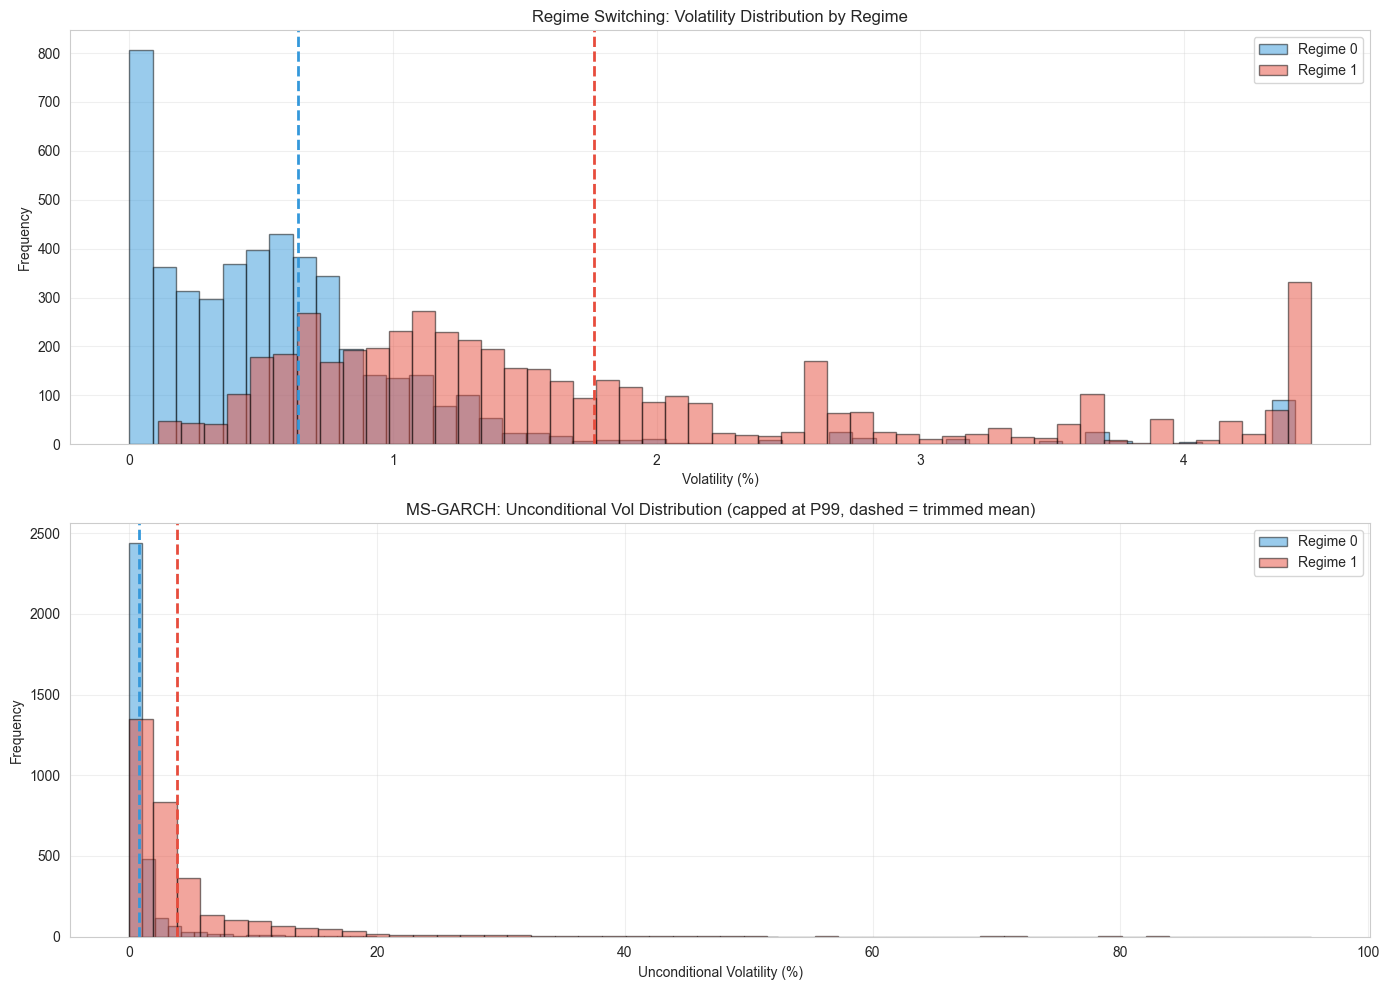

In [ ]:
# Volatility distributions (NaN-safe — drops near-IGARCH rows)
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Regime Switching
axes[0].hist(rs_params['regime_0_vol']*100, bins=50, alpha=0.5, label='Regime 0', color='#3498db', edgecolor='black')
axes[0].hist(rs_params['regime_1_vol']*100, bins=50, alpha=0.5, label='Regime 1', color='#e74c3c', edgecolor='black')
axes[0].axvline(rs_params['regime_0_vol'].mean()*100, color='#3498db', linestyle='--', linewidth=2)
axes[0].axvline(rs_params['regime_1_vol'].mean()*100, color='#e74c3c', linestyle='--', linewidth=2)
axes[0].set_xlabel('Volatility (%)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Regime Switching: Volatility Distribution by Regime')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MS-GARCH — filter out NaN and extreme outliers (cap at P99 for visualisation)
v0 = ms_garch['uncond_vol_0'].dropna() * 100
v1 = ms_garch['uncond_vol_1'].dropna() * 100
cap = max(v0.quantile(0.99), v1.quantile(0.99))  # visual cap
axes[1].hist(v0[v0 <= cap], bins=50, alpha=0.5, label='Regime 0', color='#3498db', edgecolor='black')
axes[1].hist(v1[v1 <= cap], bins=50, alpha=0.5, label='Regime 1', color='#e74c3c', edgecolor='black')
axes[1].axvline(trimmed_mean(ms_garch['uncond_vol_0'])*100, color='#3498db', linestyle='--', linewidth=2)
axes[1].axvline(trimmed_mean(ms_garch['uncond_vol_1'])*100, color='#e74c3c', linestyle='--', linewidth=2)
axes[1].set_xlabel('Unconditional Volatility (%)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('MS-GARCH: Unconditional Vol Distribution (capped at P99, dashed = trimmed mean)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Rows with unconditional vol > 10%: 481 / 3264
Unique firms involved: 33

Per-firm summary of extreme unconditional volatilities:


,n_extreme,date_min,date_max,max_vol_0,max_vol_1,median_p0,median_p1
gvkey,,,,,,,
15549,78,2017-01-31,2024-05-31,52.348089,100.000000,0.790426,0.966326
221616,9,2020-06-30,2022-05-31,0.962182,100.000000,0.938403,0.995000
15532,64,2017-01-31,2024-12-31,31.251880,100.000000,0.884566,0.968104
15617,33,2020-03-31,2024-07-31,44.463753,100.000000,0.885681,0.995000
16348,30,2017-12-29,2023-11-30,15.783316,100.000000,0.659458,0.991770
23671,18,2017-01-31,2023-11-30,3.375614,73.168471,0.690149,0.967715
103487,23,2018-01-31,2023-11-30,16.669720,71.894631,0.760793,0.885658
101204,8,2023-06-30,2024-05-31,0.958711,70.710787,0.691890,0.800000
19349,4,2020-11-30,2023-04-28,1.161278,70.710678,0.715375,0.914585



Top 20 most extreme individual (firm × date) observations:


,gvkey,date,omega_0,alpha_0,beta_0,persistence_0,uncond_vol_0,omega_1,alpha_1,beta_1,persistence_1,uncond_vol_1
267,15549,2023-04-28,0.000168,0.253371,0.349717,0.603089,2.058078,0.005,0.331072,0.663928,0.995,100.0
98,15532,2017-03-31,0.000108,0.117370,0.483527,0.600897,1.646976,0.005,0.333665,0.661335,0.995,100.0
145,15532,2021-02-26,0.000200,0.218797,0.735126,0.953924,6.580758,0.005,0.287307,0.707693,0.995,100.0
146,15532,2021-03-31,0.000236,0.251162,0.519613,0.770775,3.208859,0.005,0.312384,0.682616,0.995,100.0
156,15532,2022-01-31,0.000012,0.264896,0.335104,0.600000,0.549987,0.005,0.312005,0.682995,0.995,100.0
194,15549,2017-03-31,0.000518,0.016492,0.847826,0.864318,6.181044,0.005,0.030644,0.964356,0.995,100.0
196,15549,2017-05-31,0.000065,0.360212,0.315000,0.675212,1.416045,0.005,0.426629,0.568371,0.995,100.0
197,15549,2017-06-30,0.000174,0.020124,0.961592,0.981716,9.757809,0.005,0.318419,0.676581,0.995,100.0
200,15549,2017-09-29,0.000561,0.044853,0.555147,0.600000,3.745937,0.005,0.219645,0.775355,0.995,100.0
202,15549,2017-11-30,0.004335,0.073618,0.526382,0.600000,10.410833,0.005,0.069687,0.925313,0.995,100.0


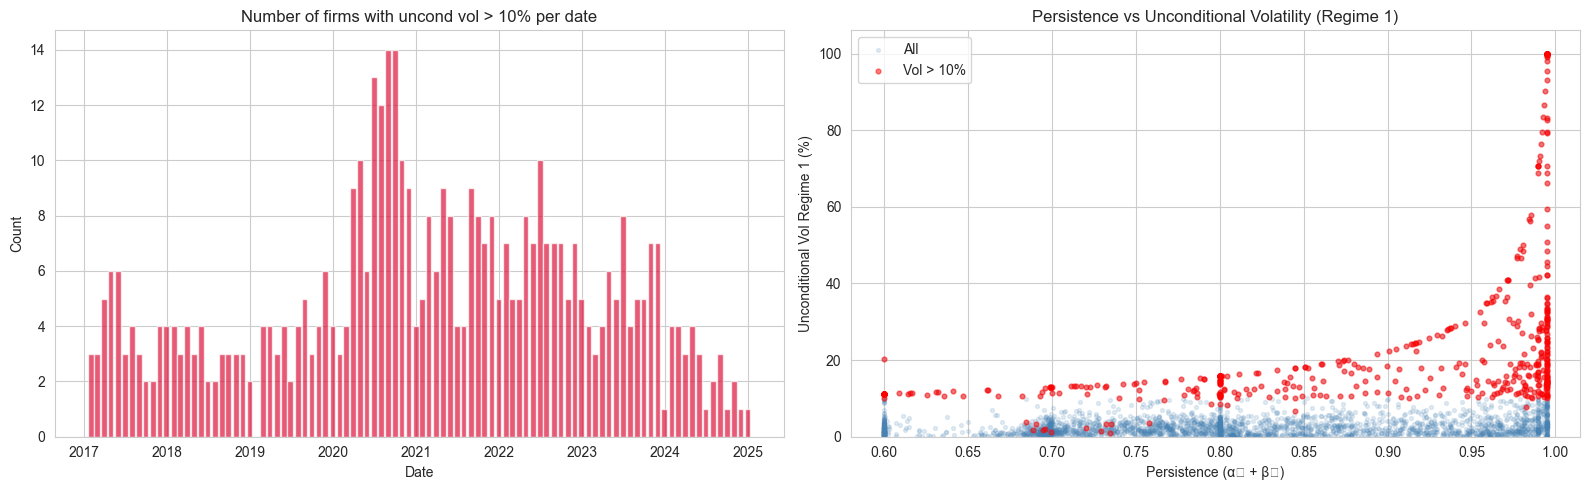

In [ ]:


# Compute unconditional vol for each regime: sqrt(omega / (1 - alpha - beta))
ms_garch['persistence_0'] = ms_garch['alpha_0'] + ms_garch['beta_0']
ms_garch['persistence_1'] = ms_garch['alpha_1'] + ms_garch['beta_1']
ms_garch['uncond_var_0']  = ms_garch['omega_0'] / (1 - ms_garch['persistence_0'])
ms_garch['uncond_var_1']  = ms_garch['omega_1'] / (1 - ms_garch['persistence_1'])
ms_garch['uncond_vol_0']  = np.sqrt(ms_garch['uncond_var_0'].clip(lower=0)) * 100  # in %
ms_garch['uncond_vol_1']  = np.sqrt(ms_garch['uncond_var_1'].clip(lower=0)) * 100  # in %

# Flag extreme rows (unconditional vol > 10% in either regime) 
THRESHOLD = 10  # percent
extreme = ms_garch[
    (ms_garch['uncond_vol_0'] > THRESHOLD) | (ms_garch['uncond_vol_1'] > THRESHOLD)
].copy()

print(f"Rows with unconditional vol > {THRESHOLD}%: {len(extreme)} / {len(ms_garch)}")
print(f"Unique firms involved: {extreme['gvkey'].nunique()}\n")

# Per-firm summary of extreme observations 
extreme_summary = (
    extreme
    .groupby('gvkey')
    .agg(
        n_extreme   = ('date', 'size'),
        date_min    = ('date', 'min'),
        date_max    = ('date', 'max'),
        max_vol_0   = ('uncond_vol_0', 'max'),
        max_vol_1   = ('uncond_vol_1', 'max'),
        median_p0   = ('persistence_0', 'median'),
        median_p1   = ('persistence_1', 'median'),
    )
    .sort_values('max_vol_1', ascending=False)
)
print("Per-firm summary of extreme unconditional volatilities:")
display(extreme_summary)

# Show the top 20 most extreme individual observations 
print("\nTop 20 most extreme individual (firm × date) observations:")
top_extreme = (
    extreme
    .assign(max_uncond_vol=lambda d: d[['uncond_vol_0','uncond_vol_1']].max(axis=1))
    .nlargest(20, 'max_uncond_vol')
    [['gvkey','date','omega_0','alpha_0','beta_0','persistence_0','uncond_vol_0',
      'omega_1','alpha_1','beta_1','persistence_1','uncond_vol_1']]
)
display(top_extreme)

extreme_by_date = extreme.groupby('date').size()
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(extreme_by_date.index, extreme_by_date.values, width=25, color='crimson', alpha=0.7)
axes[0].set_title(f'Number of firms with uncond vol > {THRESHOLD}% per date')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Count')

# Scatter: persistence vs unconditional vol (regime 1)
axes[1].scatter(ms_garch['persistence_1'], ms_garch['uncond_vol_1'],
                alpha=0.15, s=8, color='steelblue', label='All')
axes[1].scatter(extreme['persistence_1'], extreme['uncond_vol_1'],
                alpha=0.5, s=12, color='red', label=f'Vol > {THRESHOLD}%')
axes[1].set_xlabel('Persistence (α₁ + β₁)')
axes[1].set_ylabel('Unconditional Vol Regime 1 (%)')
axes[1].set_title('Persistence vs Unconditional Volatility (Regime 1)')
axes[1].legend()
axes[1].set_ylim(0, ms_garch['uncond_vol_1'].quantile(0.99)*1.1)

plt.tight_layout()
plt.show()


Effect of different persistence caps on MS-GARCH unconditional volatility:



,persistence_cap,rows_kept,rows_excluded,pct_kept,max_uncond_vol_R0 (%),max_uncond_vol_R1 (%),p99_uncond_vol_R1 (%),p95_uncond_vol_R1 (%),median_uncond_vol_R1 (%)
0,0.999,3264,0,100.0%,52.3,100.0,96.4,21.2,2.46
1,0.998,3264,0,100.0%,52.3,100.0,96.4,21.2,2.46
2,0.997,3264,0,100.0%,52.3,100.0,96.4,21.2,2.46
3,0.995,3231,33,99.0%,52.3,100.0,94.7,20.5,2.46
4,0.993,2856,408,87.5%,38.1,83.4,35.3,15.8,2.33
5,0.990,2677,587,82.0%,38.1,68.8,28.9,14.9,2.39
6,0.985,2496,768,76.5%,31.3,56.7,25.9,14.3,2.38
7,0.980,2361,903,72.3%,31.3,47.1,24.7,14.1,2.39
8,0.975,2255,1009,69.1%,31.3,41.0,24.0,13.6,2.40
9,0.970,2185,1079,66.9%,31.3,38.5,20.5,13.2,2.39


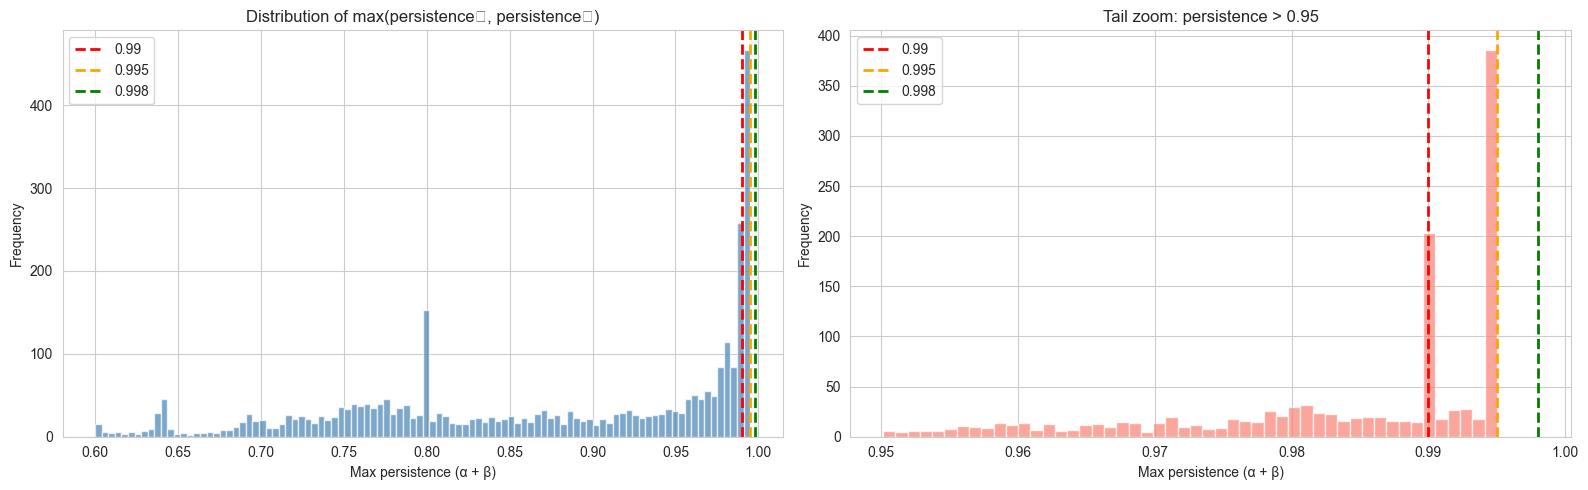

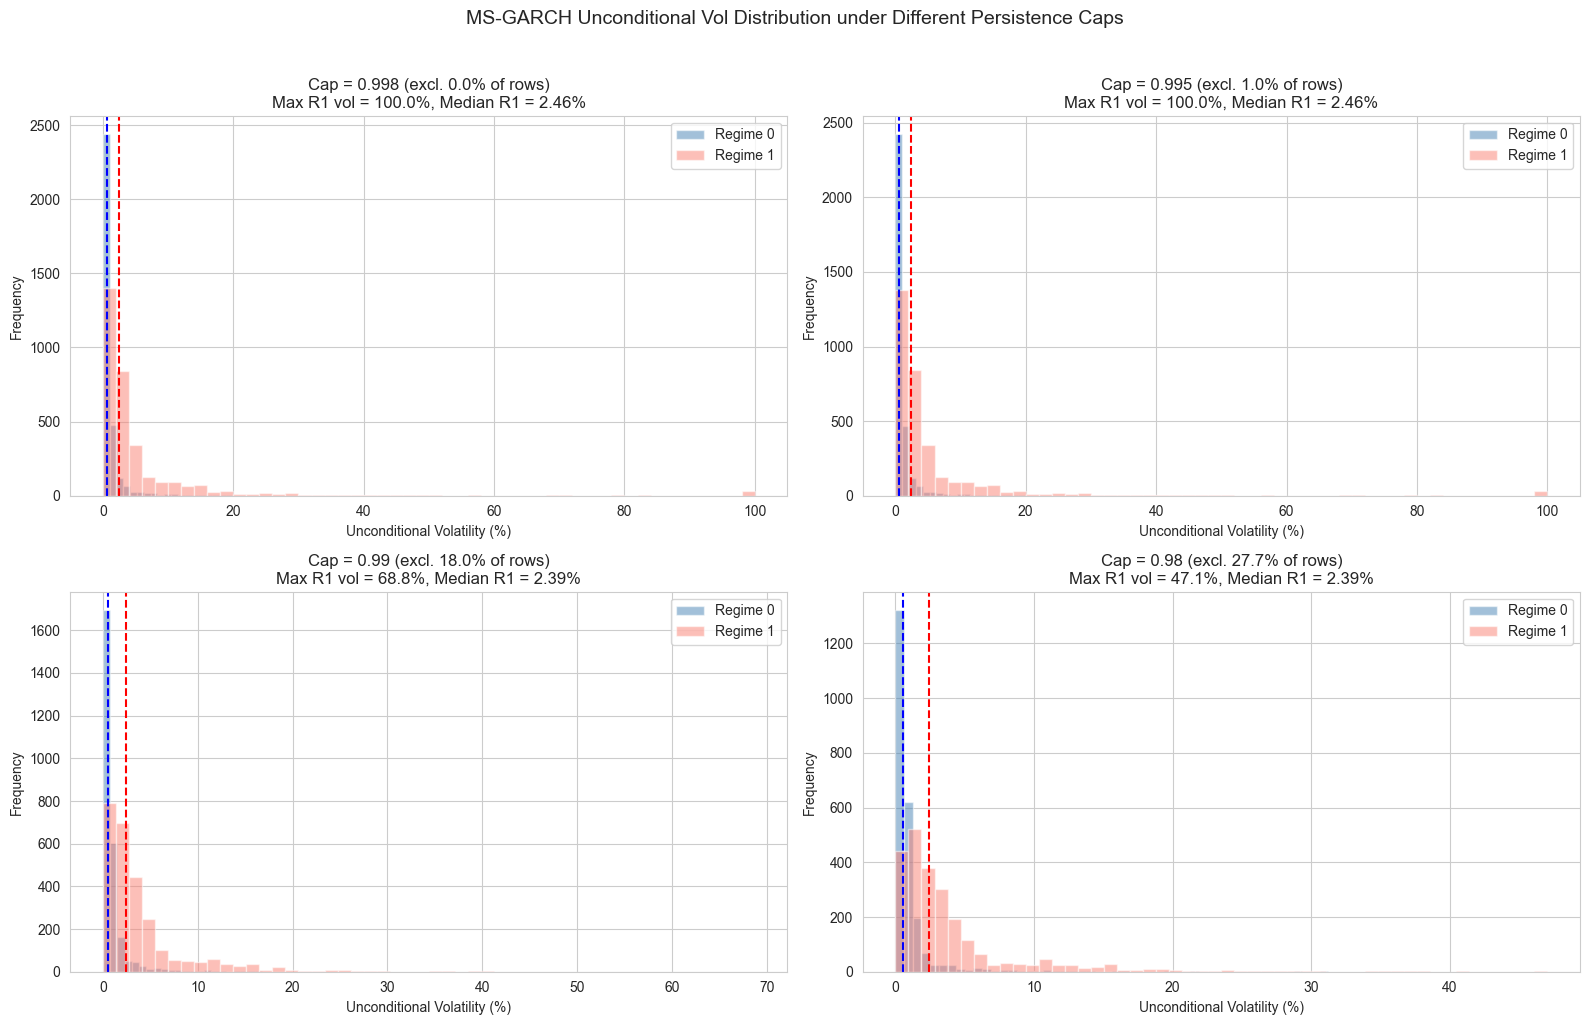

In [ ]:

# Find the right persistence cap 
# Test a range of persistence thresholds and see how many rows are excluded
# and what the resulting max unconditional vol looks like.

thresholds = [0.999, 0.998, 0.997, 0.995, 0.993, 0.99, 0.985, 0.98, 0.975, 0.97, 0.96, 0.95]

# Compute persistence for both regimes
p0 = ms_garch['alpha_0'] + ms_garch['beta_0']
p1 = ms_garch['alpha_1'] + ms_garch['beta_1']
max_p = np.maximum(p0, p1)

rows = []
for thr in thresholds:
    mask = max_p < thr
    kept = mask.sum()
    pct_kept = kept / len(ms_garch) * 100
    
    # Compute uncond vol for kept rows
    uv0 = np.sqrt((ms_garch.loc[mask, 'omega_0'] / (1 - p0[mask])).clip(lower=0)) * 100
    uv1 = np.sqrt((ms_garch.loc[mask, 'omega_1'] / (1 - p1[mask])).clip(lower=0)) * 100
    
    rows.append({
        'persistence_cap': thr,
        'rows_kept': kept,
        'rows_excluded': len(ms_garch) - kept,
        'pct_kept': f'{pct_kept:.1f}%',
        'max_uncond_vol_R0 (%)': f'{uv0.max():.1f}',
        'max_uncond_vol_R1 (%)': f'{uv1.max():.1f}',
        'p99_uncond_vol_R1 (%)': f'{uv1.quantile(0.99):.1f}',
        'p95_uncond_vol_R1 (%)': f'{uv1.quantile(0.95):.1f}',
        'median_uncond_vol_R1 (%)': f'{uv1.median():.2f}',
    })

cap_analysis = pd.DataFrame(rows)
print("Effect of different persistence caps on MS-GARCH unconditional volatility:\n")
display(cap_analysis)

# ── Visual: distribution of max persistence across all rows 
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: histogram of max(persistence_0, persistence_1)
axes[0].hist(max_p, bins=100, color='steelblue', alpha=0.7, edgecolor='white')
axes[0].axvline(0.99, color='red', ls='--', lw=2, label='0.99')
axes[0].axvline(0.995, color='orange', ls='--', lw=2, label='0.995')
axes[0].axvline(0.998, color='green', ls='--', lw=2, label='0.998')
axes[0].set_xlabel('Max persistence (α + β)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of max(persistence₀, persistence₁)')
axes[0].legend()

# Right: zoom into the high-persistence tail
tail = max_p[max_p > 0.95]
axes[1].hist(tail, bins=50, color='salmon', alpha=0.7, edgecolor='white')
axes[1].axvline(0.99, color='red', ls='--', lw=2, label='0.99')
axes[1].axvline(0.995, color='orange', ls='--', lw=2, label='0.995')
axes[1].axvline(0.998, color='green', ls='--', lw=2, label='0.998')
axes[1].set_xlabel('Max persistence (α + β)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Tail zoom: persistence > 0.95')
axes[1].legend()

plt.tight_layout()
plt.show()

# ── Show resulting vol distribution for a few candidate caps 
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
candidate_caps = [0.998, 0.995, 0.99, 0.98]

for ax, cap_val in zip(axes.flat, candidate_caps):
    mask = max_p < cap_val
    uv0 = np.sqrt((ms_garch.loc[mask, 'omega_0'] / (1 - p0[mask])).clip(lower=0)) * 100
    uv1 = np.sqrt((ms_garch.loc[mask, 'omega_1'] / (1 - p1[mask])).clip(lower=0)) * 100
    
    ax.hist(uv0, bins=50, alpha=0.5, color='steelblue', label='Regime 0')
    ax.hist(uv1, bins=50, alpha=0.5, color='salmon', label='Regime 1')
    ax.axvline(uv0.median(), color='blue', ls='--', lw=1.5)
    ax.axvline(uv1.median(), color='red', ls='--', lw=1.5)
    excluded_pct = (1 - mask.sum()/len(ms_garch)) * 100
    ax.set_title(f'Cap = {cap_val} (excl. {excluded_pct:.1f}% of rows)\n'
                 f'Max R1 vol = {uv1.max():.1f}%, Median R1 = {uv1.median():.2f}%')
    ax.set_xlabel('Unconditional Volatility (%)')
    ax.set_ylabel('Frequency')
    ax.legend()

plt.suptitle('MS-GARCH Unconditional Vol Distribution under Different Persistence Caps', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## 7. Transition Probability Analysis

In [ ]:
# Analyze transition probabilities
print('='*80)
print('REGIME SWITCHING - TRANSITION PROBABILITIES')
print('='*80)
print(f"P(stay in Regime 0 | in Regime 0): {rs_params['transition_prob_00'].mean():.4f}")
print(f"P(switch to Regime 1 | in Regime 0): {rs_params['transition_prob_01'].mean():.4f}")
print(f"P(switch to Regime 0 | in Regime 1): {rs_params['transition_prob_10'].mean():.4f}")
print(f"P(stay in Regime 1 | in Regime 1): {rs_params['transition_prob_11'].mean():.4f}")

print('\n' + '='*80)
print('MS-GARCH - TRANSITION PROBABILITIES')
print('='*80)
print(f"P(stay in Regime 0 | in Regime 0): {ms_garch['p00'].mean():.4f}")
print(f"P(switch to Regime 1 | in Regime 0): {(1 - ms_garch['p00']).mean():.4f}")
print(f"P(switch to Regime 0 | in Regime 1): {(1 - ms_garch['p11']).mean():.4f}")
print(f"P(stay in Regime 1 | in Regime 1): {ms_garch['p11'].mean():.4f}")

REGIME SWITCHING - TRANSITION PROBABILITIES
P(stay in Regime 0 | in Regime 0): 0.6943
P(switch to Regime 1 | in Regime 0): 0.3057
P(switch to Regime 0 | in Regime 1): 0.2428
P(stay in Regime 1 | in Regime 1): 0.7572

MS-GARCH - TRANSITION PROBABILITIES
P(stay in Regime 0 | in Regime 0): 0.9018
P(switch to Regime 1 | in Regime 0): 0.0982
P(switch to Regime 0 | in Regime 1): 0.1182
P(stay in Regime 1 | in Regime 1): 0.8818


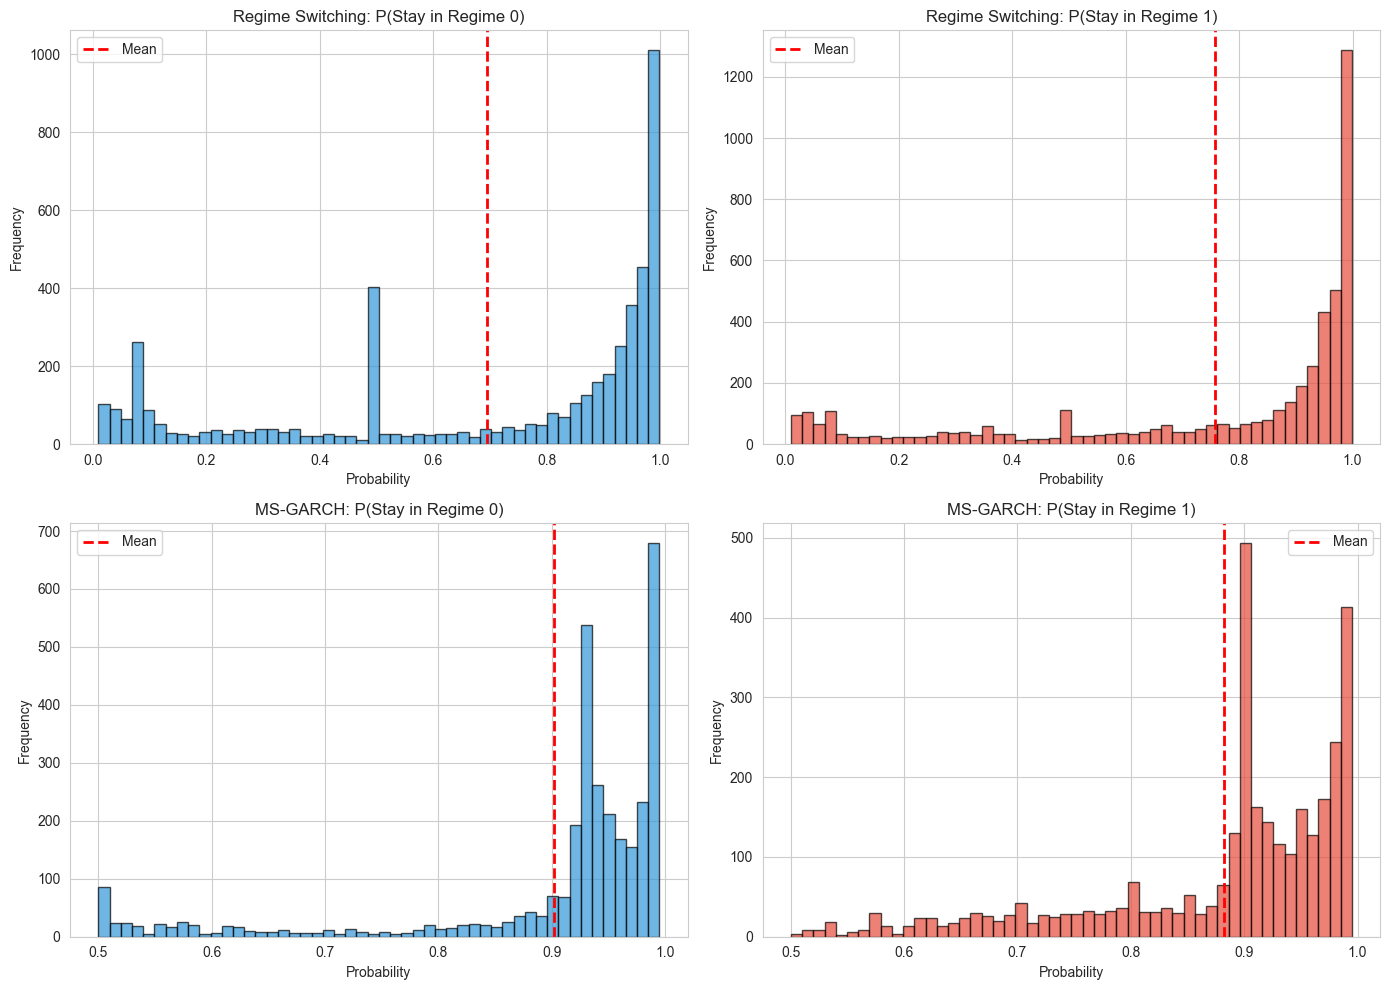

In [ ]:
# Visualize transition probabilities
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Regime Switching - Persistence
axes[0, 0].hist(rs_params['transition_prob_00'], bins=50, color='#3498db', alpha=0.7, edgecolor='black')
axes[0, 0].axvline(rs_params['transition_prob_00'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[0, 0].set_xlabel('Probability')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Regime Switching: P(Stay in Regime 0)')
axes[0, 0].legend()

axes[0, 1].hist(rs_params['transition_prob_11'], bins=50, color='#e74c3c', alpha=0.7, edgecolor='black')
axes[0, 1].axvline(rs_params['transition_prob_11'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[0, 1].set_xlabel('Probability')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Regime Switching: P(Stay in Regime 1)')
axes[0, 1].legend()

# MS-GARCH - Persistence
axes[1, 0].hist(ms_garch['p00'], bins=50, color='#3498db', alpha=0.7, edgecolor='black')
axes[1, 0].axvline(ms_garch['p00'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[1, 0].set_xlabel('Probability')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('MS-GARCH: P(Stay in Regime 0)')
axes[1, 0].legend()

axes[1, 1].hist(ms_garch['p11'], bins=50, color='#e74c3c', alpha=0.7, edgecolor='black')
axes[1, 1].axvline(ms_garch['p11'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[1, 1].set_xlabel('Probability')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('MS-GARCH: P(Stay in Regime 1)')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

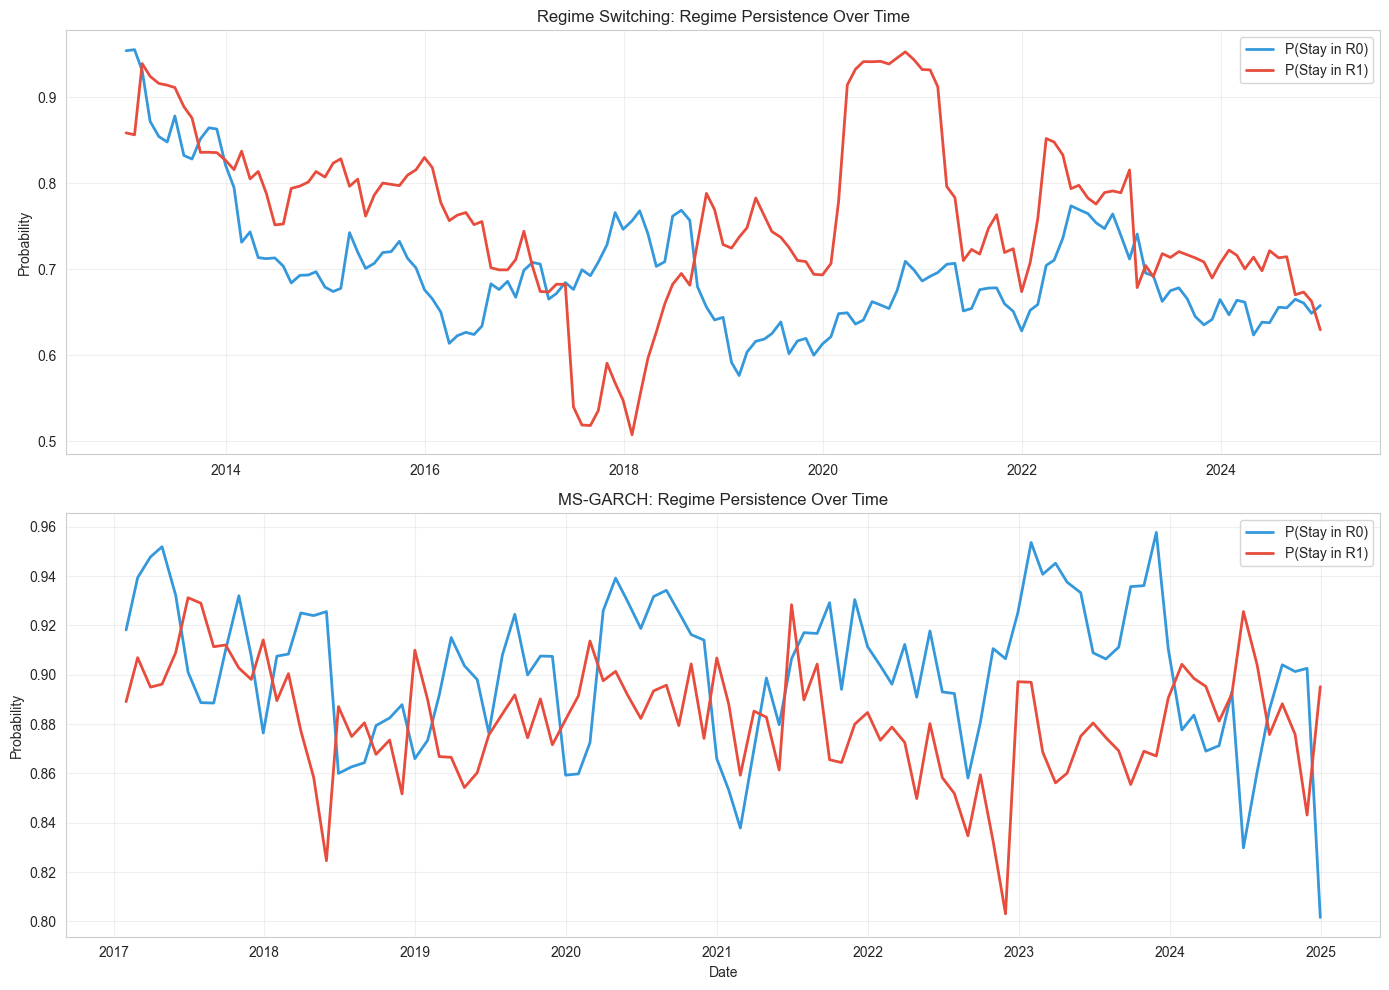

In [ ]:
# Transition probabilities over time
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Regime Switching
rs_trans_time = rs_params.groupby('date')[['transition_prob_00', 'transition_prob_11']].mean()
axes[0].plot(rs_trans_time.index, rs_trans_time['transition_prob_00'], label='P(Stay in R0)', color='#3498db', linewidth=2)
axes[0].plot(rs_trans_time.index, rs_trans_time['transition_prob_11'], label='P(Stay in R1)', color='#e74c3c', linewidth=2)
axes[0].set_ylabel('Probability')
axes[0].set_title('Regime Switching: Regime Persistence Over Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MS-GARCH
ms_trans_time = ms_garch.groupby('date')[['p00', 'p11']].mean()
axes[1].plot(ms_trans_time.index, ms_trans_time['p00'], label='P(Stay in R0)', color='#3498db', linewidth=2)
axes[1].plot(ms_trans_time.index, ms_trans_time['p11'], label='P(Stay in R1)', color='#e74c3c', linewidth=2)
axes[1].set_ylabel('Probability')
axes[1].set_xlabel('Date')
axes[1].set_title('MS-GARCH: Regime Persistence Over Time')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Time Series Visualization of Regimes



In [ ]:
# Select a company to analyze
sample_gvkey = rs_params['gvkey'].iloc[0]
print(f"Analyzing company: {sample_gvkey}")

# Filter data for this company
rs_company = rs_params[rs_params['gvkey'] == sample_gvkey].sort_values('date')
ms_company = ms_garch[ms_garch['gvkey'] == sample_gvkey].sort_values('date')

Analyzing company: 14447


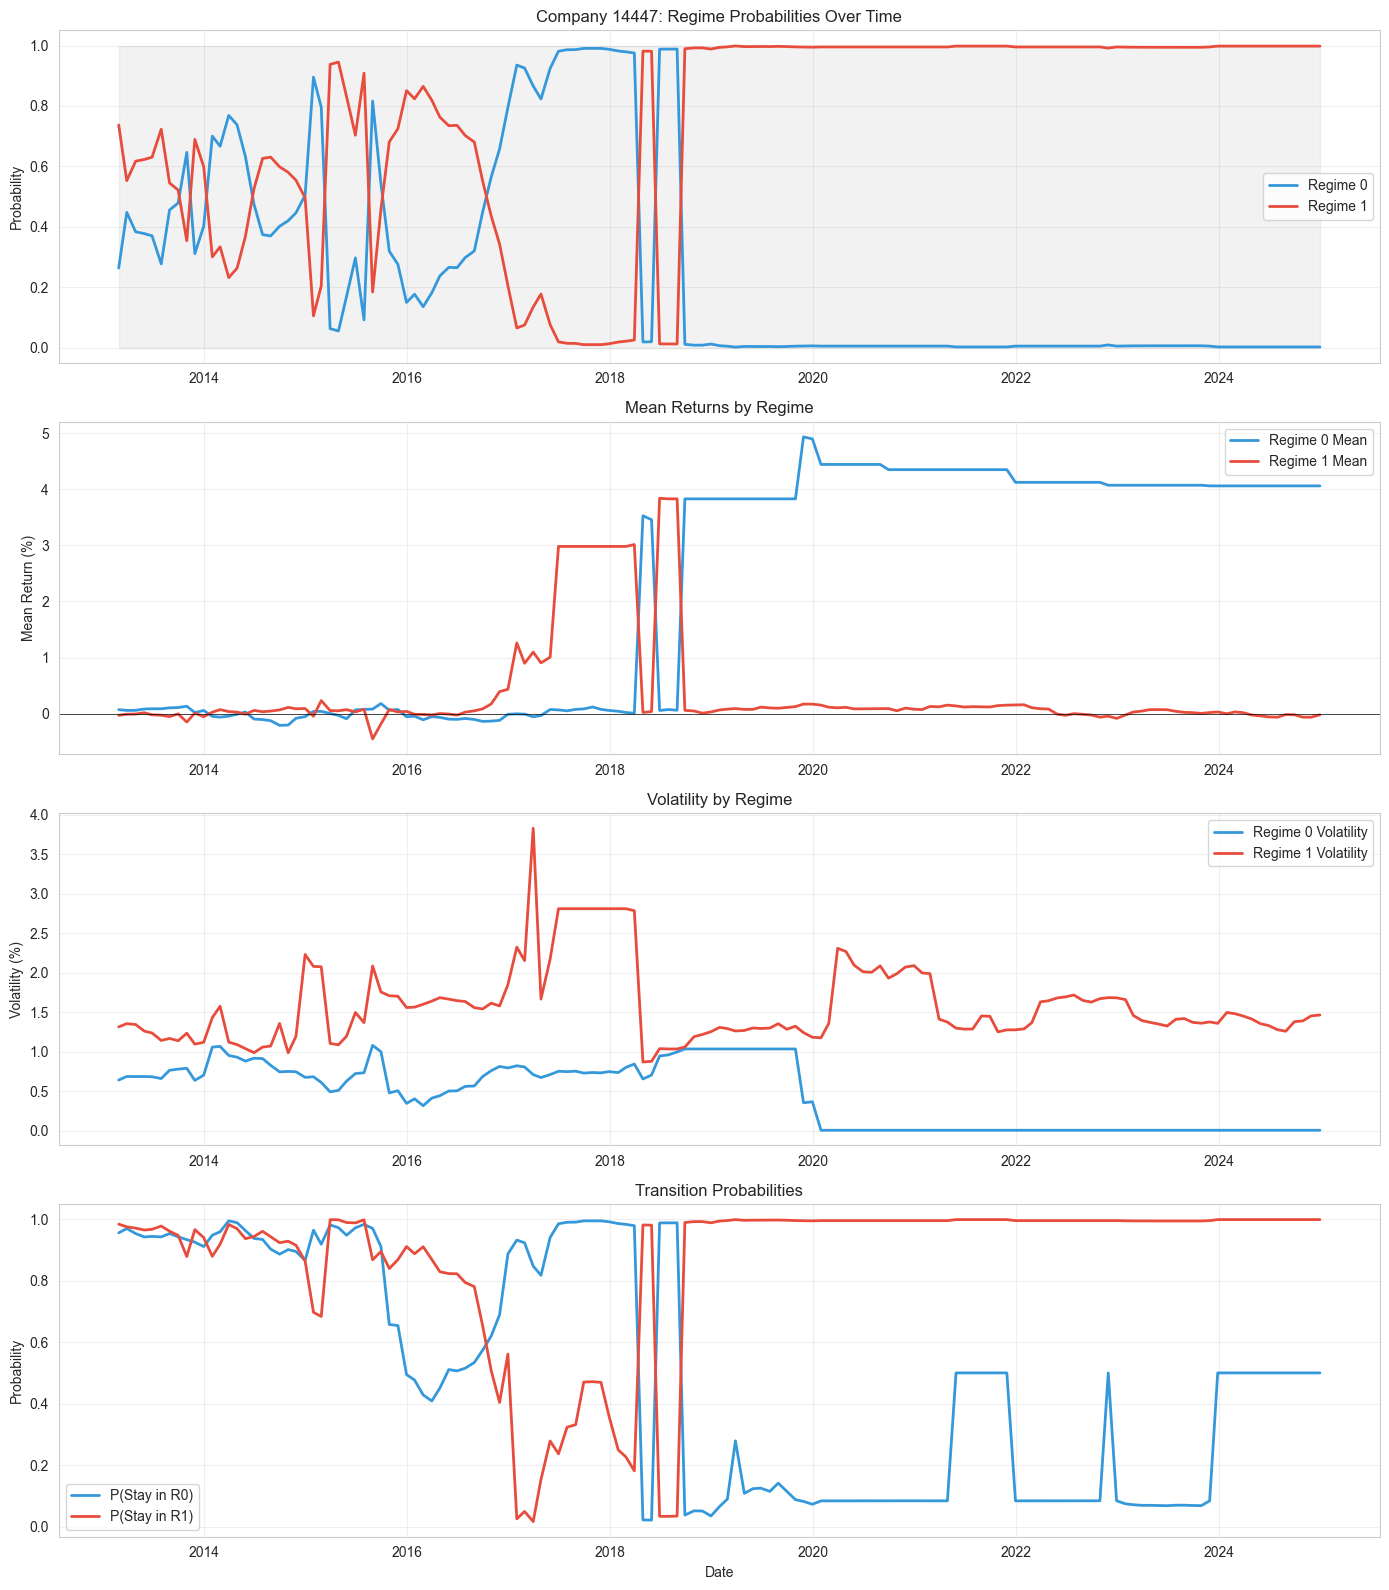

In [ ]:
# Plot regime probabilities and parameters over time
fig, axes = plt.subplots(4, 1, figsize=(14, 16))

# Regime probabilities
axes[0].plot(rs_company['date'], rs_company['steady_state_regime_0'], label='Regime 0', color='#3498db', linewidth=2)
axes[0].plot(rs_company['date'], rs_company['steady_state_regime_1'], label='Regime 1', color='#e74c3c', linewidth=2)
axes[0].fill_between(rs_company['date'], 0, 1, alpha=0.1, color='gray')
axes[0].set_ylabel('Probability')
axes[0].set_title(f'Company {sample_gvkey}: Regime Probabilities Over Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Mean returns by regime
axes[1].plot(rs_company['date'], rs_company['regime_0_mean']*100, label='Regime 0 Mean', color='#3498db', linewidth=2)
axes[1].plot(rs_company['date'], rs_company['regime_1_mean']*100, label='Regime 1 Mean', color='#e74c3c', linewidth=2)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].set_ylabel('Mean Return (%)')
axes[1].set_title('Mean Returns by Regime')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Volatility by regime
axes[2].plot(rs_company['date'], rs_company['regime_0_vol']*100, label='Regime 0 Volatility', color='#3498db', linewidth=2)
axes[2].plot(rs_company['date'], rs_company['regime_1_vol']*100, label='Regime 1 Volatility', color='#e74c3c', linewidth=2)
axes[2].set_ylabel('Volatility (%)')
axes[2].set_title('Volatility by Regime')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# Transition probabilities
axes[3].plot(rs_company['date'], rs_company['transition_prob_00'], label='P(Stay in R0)', color='#3498db', linewidth=2)
axes[3].plot(rs_company['date'], rs_company['transition_prob_11'], label='P(Stay in R1)', color='#e74c3c', linewidth=2)
axes[3].set_ylabel('Probability')
axes[3].set_xlabel('Date')
axes[3].set_title('Transition Probabilities')
axes[3].legend()
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Statistical Tests for Regime Differences

In [ ]:
# Perform t-tests to check if regime parameters are significantly different
from scipy.stats import ttest_rel, ttest_ind

print('='*80)
print('REGIME SWITCHING - STATISTICAL TESTS FOR PARAMETER DIFFERENCES')
print('='*80)

# Test mean returns
t_stat, p_value = ttest_rel(rs_params['regime_0_mean'], rs_params['regime_1_mean'])
print(f"\nMean Returns:")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.4e}")
print(f"  Significant at 5% level: {'Yes' if p_value < 0.05 else 'No'}")

# Test volatility
t_stat, p_value = ttest_rel(rs_params['regime_0_vol'], rs_params['regime_1_vol'])
print(f"\nVolatility:")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.4e}")
print(f"  Significant at 5% level: {'Yes' if p_value < 0.05 else 'No'}")

# Test degrees of freedom
t_stat, p_value = ttest_rel(rs_params['regime_0_nu'], rs_params['regime_1_nu'])
print(f"\nDegrees of Freedom (nu):")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.4e}")
print(f"  Significant at 5% level: {'Yes' if p_value < 0.05 else 'No'}")

print('\n' + '='*80)
print('MS-GARCH - STATISTICAL TESTS FOR PARAMETER DIFFERENCES')
print('='*80)

# Test mean returns
t_stat, p_value = ttest_rel(ms_garch['mu_0'], ms_garch['mu_1'])
print(f"\nMean Returns:")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.4e}")
print(f"  Significant at 5% level: {'Yes' if p_value < 0.05 else 'No'}")

# Test GARCH parameters
t_stat, p_value = ttest_rel(ms_garch['alpha_0'], ms_garch['alpha_1'])
print(f"\nAlpha (ARCH effect):")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.4e}")
print(f"  Significant at 5% level: {'Yes' if p_value < 0.05 else 'No'}")

t_stat, p_value = ttest_rel(ms_garch['beta_0'], ms_garch['beta_1'])
print(f"\nBeta (GARCH effect):")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.4e}")
print(f"  Significant at 5% level: {'Yes' if p_value < 0.05 else 'No'}")

REGIME SWITCHING - STATISTICAL TESTS FOR PARAMETER DIFFERENCES

Mean Returns:
  t-statistic: 5.6490
  p-value: 1.7066e-08
  Significant at 5% level: Yes

Volatility:
  t-statistic: -76.0207
  p-value: 0.0000e+00
  Significant at 5% level: Yes

Degrees of Freedom (nu):
  t-statistic: 17.4997
  p-value: 1.5508e-66
  Significant at 5% level: Yes

MS-GARCH - STATISTICAL TESTS FOR PARAMETER DIFFERENCES

Mean Returns:
  t-statistic: 2.6981
  p-value: 7.0093e-03
  Significant at 5% level: Yes

Alpha (ARCH effect):
  t-statistic: -39.0385
  p-value: 6.8503e-274
  Significant at 5% level: Yes

Beta (GARCH effect):
  t-statistic: 19.2095
  p-value: 5.3483e-78
  Significant at 5% level: Yes


In [ ]:
# Effect sizes (Cohen's d)
def cohens_d(x, y):
    """Calculate Cohen's d for effect size"""
    nx = len(x)
    ny = len(y)
    dof = nx + ny - 2
    return (np.mean(x) - np.mean(y)) / np.sqrt(((nx-1)*np.std(x, ddof=1)**2 + (ny-1)*np.std(y, ddof=1)**2) / dof)

print('='*80)
print('EFFECT SIZES (Cohen\'s d)')
print('='*80)
print("\nRegime Switching:")
print(f"  Mean Returns: d = {cohens_d(rs_params['regime_0_mean'], rs_params['regime_1_mean']):.4f}")
print(f"  Volatility: d = {cohens_d(rs_params['regime_0_vol'], rs_params['regime_1_vol']):.4f}")
print(f"  Degrees of Freedom: d = {cohens_d(rs_params['regime_0_nu'], rs_params['regime_1_nu']):.4f}")

print("\nMS-GARCH:")
print(f"  Mean Returns: d = {cohens_d(ms_garch['mu_0'], ms_garch['mu_1']):.4f}")
print(f"  Alpha: d = {cohens_d(ms_garch['alpha_0'], ms_garch['alpha_1']):.4f}")
print(f"  Beta: d = {cohens_d(ms_garch['beta_0'], ms_garch['beta_1']):.4f}")


EFFECT SIZES (Cohen's d)

Regime Switching:
  Mean Returns: d = 0.1151
  Volatility: d = -1.1220
  Degrees of Freedom: d = 0.3586

MS-GARCH:
  Mean Returns: d = 0.0031
  Alpha: d = -0.7639
  Beta: d = 0.3879

Interpretation: |d| < 0.2 = small, 0.2-0.8 = medium, > 0.8 = large effect


## 10. Cross-Sectional Analysis Across Companies

In [ ]:
# Compare characteristics across companies
company_stats_rs = rs_params.groupby('gvkey').agg({
    'regime_0_mean': 'mean',
    'regime_1_mean': 'mean',
    'regime_0_vol': 'mean',
    'regime_1_vol': 'mean',
    'steady_state_regime_0': 'mean',
    'steady_state_regime_1': 'mean',
    'duration_regime_0': 'mean',
    'duration_regime_1': 'mean'
}).reset_index()

# Add volatility ratio
company_stats_rs['vol_ratio'] = company_stats_rs['regime_1_vol'] / company_stats_rs['regime_0_vol']

print('Company-Level Statistics (Regime Switching):')
display(company_stats_rs.head(10))

Company-Level Statistics (Regime Switching):


,gvkey,regime_0_mean,regime_1_mean,regime_0_vol,regime_1_vol,steady_state_regime_0,steady_state_regime_1,duration_regime_0,duration_regime_1,vol_ratio
0,14447,0.022539,0.003672,0.004452,0.015819,0.261312,0.738688,17.979748,254.038037,3.553290
1,15532,0.195397,0.021423,0.002092,0.031879,0.223917,0.776083,19.453911,553.574704,15.240237
2,15549,0.013215,0.038255,0.015521,0.043212,0.622314,0.377686,65.370830,99.112910,2.784036
3,15617,-0.027281,0.002384,0.008729,0.038809,0.226647,0.773353,116.430198,632.825654,4.446140
4,15677,0.000138,-0.003425,0.001310,0.012323,0.833544,0.166456,83.013679,24.978039,9.403868
5,15724,0.000083,0.004331,0.001106,0.007325,0.730159,0.269841,77.439820,36.073174,6.623090
6,16348,-0.197684,-0.449185,0.035312,0.044372,0.636830,0.363170,597.864407,144.634177,1.256570
7,17436,0.000063,0.001159,0.007803,0.016629,0.603557,0.396443,42.459714,16.265217,2.131037
8,17452,0.002587,0.000770,0.005520,0.012409,0.522728,0.477272,42.674724,41.736100,2.248155
9,19349,0.000379,0.000527,0.005552,0.013090,0.520422,0.479578,24.002556,15.481695,2.357603


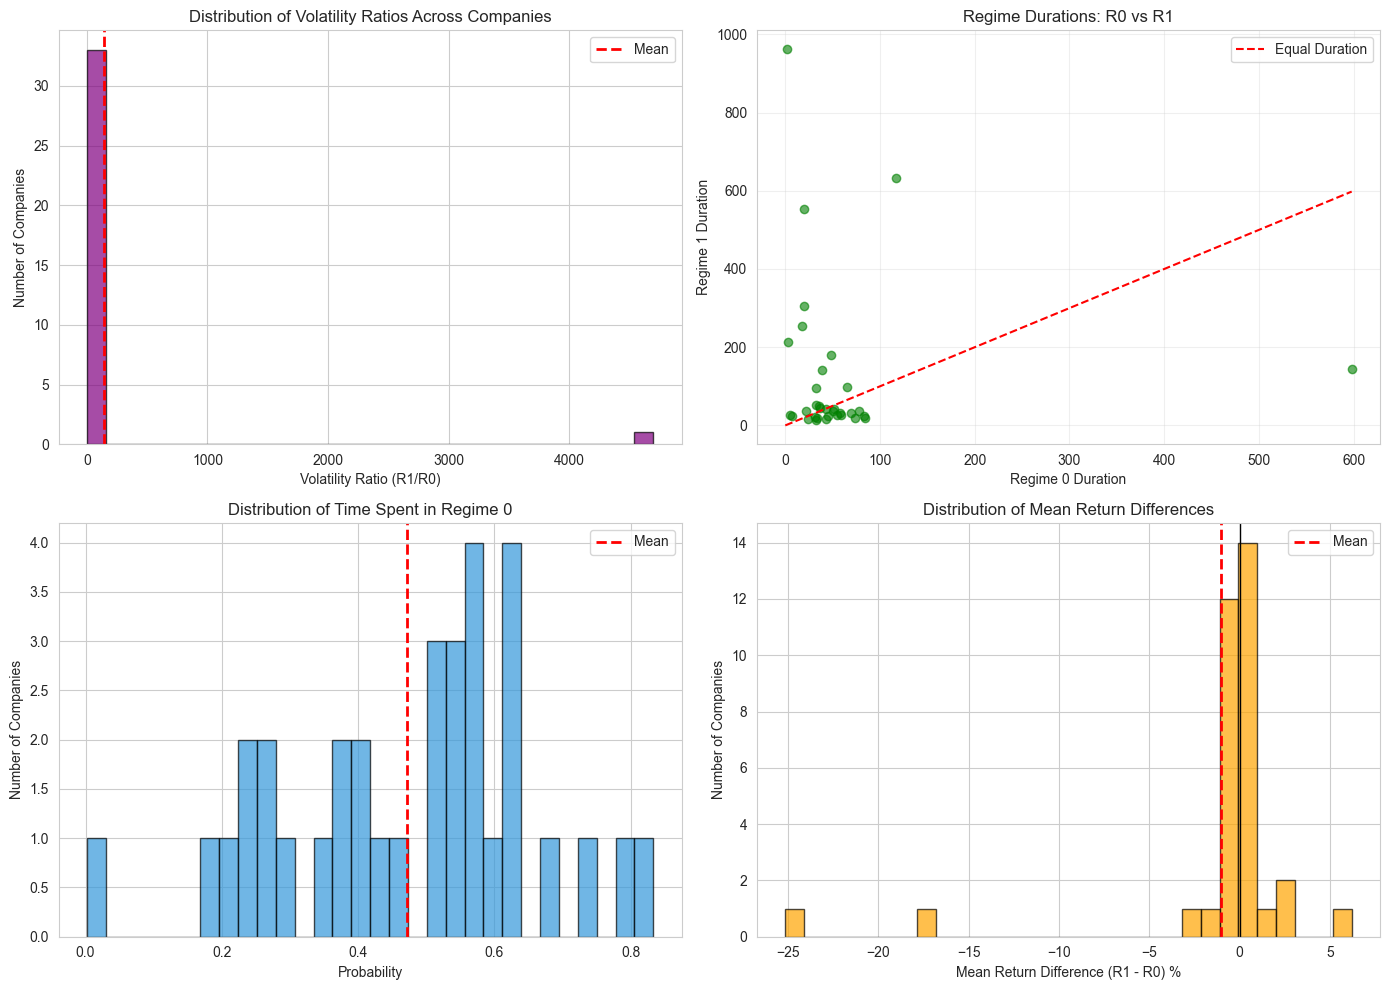

In [ ]:
# Visualize company-level differences
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Volatility ratio across companies
axes[0, 0].hist(company_stats_rs['vol_ratio'], bins=30, color='purple', alpha=0.7, edgecolor='black')
axes[0, 0].axvline(company_stats_rs['vol_ratio'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[0, 0].set_xlabel('Volatility Ratio (R1/R0)')
axes[0, 0].set_ylabel('Number of Companies')
axes[0, 0].set_title('Distribution of Volatility Ratios Across Companies')
axes[0, 0].legend()

# Duration comparison
axes[0, 1].scatter(company_stats_rs['duration_regime_0'], company_stats_rs['duration_regime_1'], alpha=0.6, color='green')
axes[0, 1].plot([0, company_stats_rs['duration_regime_0'].max()], [0, company_stats_rs['duration_regime_0'].max()], 'r--', label='Equal Duration')
axes[0, 1].set_xlabel('Regime 0 Duration')
axes[0, 1].set_ylabel('Regime 1 Duration')
axes[0, 1].set_title('Regime Durations: R0 vs R1')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Regime frequency
axes[1, 0].hist(company_stats_rs['steady_state_regime_0'], bins=30, color='#3498db', alpha=0.7, edgecolor='black')
axes[1, 0].axvline(company_stats_rs['steady_state_regime_0'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[1, 0].set_xlabel('Probability')
axes[1, 0].set_ylabel('Number of Companies')
axes[1, 0].set_title('Distribution of Time Spent in Regime 0')
axes[1, 0].legend()

# Mean return difference
company_stats_rs['mean_diff'] = company_stats_rs['regime_1_mean'] - company_stats_rs['regime_0_mean']
axes[1, 1].hist(company_stats_rs['mean_diff']*100, bins=30, color='orange', alpha=0.7, edgecolor='black')
axes[1, 1].axvline(company_stats_rs['mean_diff'].mean()*100, color='red', linestyle='--', linewidth=2, label='Mean')
axes[1, 1].axvline(0, color='black', linestyle='-', linewidth=1)
axes[1, 1].set_xlabel('Mean Return Difference (R1 - R0) %')
axes[1, 1].set_ylabel('Number of Companies')
axes[1, 1].set_title('Distribution of Mean Return Differences')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Summary of key findings
print('='*80)
print('KEY FINDINGS SUMMARY')
print('='*80)

print('\n1. REGIME FREQUENCY:')
print(f"   - Average time in Regime 0 (RS): {rs_params['steady_state_regime_0'].mean():.2%}")
print(f"   - Average time in Regime 1 (RS): {rs_params['steady_state_regime_1'].mean():.2%}")
print(f"   - Average time in Regime 0 (MS-GARCH): {ms_garch['steady_state_regime_0'].mean():.2%}")
print(f"   - Average time in Regime 1 (MS-GARCH): {ms_garch['steady_state_regime_1'].mean():.2%}")

print('\n2. REGIME PERSISTENCE:')
print(f"   - Regime 0 expected duration (RS): {rs_params['duration_regime_0'].mean():.2f} periods")
print(f"   - Regime 1 expected duration (RS): {rs_params['duration_regime_1'].mean():.2f} periods")
print(f"   - Regime 0 expected duration (MS-GARCH): {ms_garch['duration_regime_0'].mean():.2f} periods")
print(f"   - Regime 1 expected duration (MS-GARCH): {ms_garch['duration_regime_1'].mean():.2f} periods")

print('\n3. PARAMETER DIFFERENCES:')
print(f"   - Mean return difference (RS): {(rs_params['regime_1_mean'].mean() - rs_params['regime_0_mean'].mean())*100:.4f}%")
print(f"   - Volatility ratio (RS): {(rs_params['regime_1_vol'].mean() / rs_params['regime_0_vol'].mean()):.2f}x")
print(f"   - Mean return difference (MS-GARCH): {(ms_garch['mu_1'].mean() - ms_garch['mu_0'].mean())*100:.4f}%")

print('\n4. CROSS-SECTIONAL VARIATION:')
print(f"   - Volatility ratio std dev: {company_stats_rs['vol_ratio'].std():.2f}")
print(f"   - Companies with higher vol in R1: {(company_stats_rs['vol_ratio'] > 1).sum()} / {len(company_stats_rs)}")
print(f"   - Companies with positive mean diff: {(company_stats_rs['mean_diff'] > 0).sum()} / {len(company_stats_rs)}")

print('\n' + '='*80)

KEY FINDINGS SUMMARY

1. REGIME FREQUENCY:
   - Average time in Regime 0 (RS): 47.18%
   - Average time in Regime 1 (RS): 52.82%
   - Average time in Regime 0 (MS-GARCH): 56.84%
   - Average time in Regime 1 (MS-GARCH): 43.16%

2. REGIME PERSISTENCE:
   - Regime 0 expected duration (RS): 58.98 periods
   - Regime 1 expected duration (RS): 125.25 periods
   - Regime 0 expected duration (MS-GARCH): 44.48 periods
   - Regime 1 expected duration (MS-GARCH): 29.98 periods

3. PARAMETER DIFFERENCES:
   - Mean return difference (RS): -1.0543%
   - Volatility ratio (RS): 2.76x
   - Mean return difference (MS-GARCH): -0.0731%

4. CROSS-SECTIONAL VARIATION:
   - Volatility ratio std dev: 804.66
   - Companies with higher vol in R1: 34 / 34
   - Companies with positive mean diff: 14 / 34



## 11. Leverage Group Analysis


In [ ]:
# Load merged data to get leverage information
if 'DATA_OUTPUT' in globals():
    merged_path = DATA_OUTPUT / 'merged_data_with_merton.csv'
elif 'PROJECT_ROOT' in globals():
    merged_path = PROJECT_ROOT / 'data' / 'output' / 'merged_data_with_merton.csv'
else:
    from pathlib import Path
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd / 'Seminar QF', cwd.parent]
    merged_path = None
    for candidate in candidates:
        candidate_path = candidate / 'data' / 'output' / 'merged_data_with_merton.csv'
        if candidate_path.exists():
            merged_path = candidate_path
            break
    if merged_path is None:
        tried = '\n'.join(str(c / 'data' / 'output' / 'merged_data_with_merton.csv') for c in candidates)
        raise FileNotFoundError(f'Could not locate merged_data_with_merton.csv. Tried:\n{tried}')

print(f'Using merged data file: {merged_path}')
df_merged = pd.read_csv(merged_path)
df_merged['date'] = pd.to_datetime(df_merged['date'])

# Calculate leverage ratio
df_merged['leverage_ratio'] = df_merged['liabilities_total'] / (df_merged['liabilities_total'] + df_merged['mkt_cap'])

# Calculate average leverage for each firm
firm_leverage = df_merged.groupby('gvkey').agg({
    'leverage_ratio': 'mean',
    'company': 'first'
}).reset_index()

firm_leverage.columns = ['gvkey', 'avg_leverage', 'company']

# Create leverage terciles
firm_leverage['leverage_tercile'] = pd.qcut(
    firm_leverage['avg_leverage'], 
    q=3, 
    labels=['Low Leverage', 'Mid Leverage', 'High Leverage']
)

# Get tercile boundaries
tercile_boundaries = pd.qcut(firm_leverage['avg_leverage'], q=3, retbins=True)[1]

print("Leverage Group Definitions:")
print(f"Low Leverage:  < {tercile_boundaries[1]:.2%}")
print(f"Mid Leverage:  {tercile_boundaries[1]:.2%} - {tercile_boundaries[2]:.2%}")
print(f"High Leverage: > {tercile_boundaries[2]:.2%}")

# Create leverage mapping dictionary
leverage_group_map = firm_leverage.set_index('gvkey')['leverage_tercile'].to_dict()

# Add leverage groups to regime parameter dataframes
rs_params['leverage_tercile'] = rs_params['gvkey'].map(leverage_group_map)
ms_garch['leverage_tercile'] = ms_garch['gvkey'].map(leverage_group_map)

print(f"\nLeverage groups assigned")
print(f"  Low Leverage: {(rs_params['leverage_tercile'] == 'Low Leverage').sum()} observations")
print(f"  Mid Leverage: {(rs_params['leverage_tercile'] == 'Mid Leverage').sum()} observations")
print(f"  High Leverage: {(rs_params['leverage_tercile'] == 'High Leverage').sum()} observations")

Using merged data file: C:\Users\Chase\Downloads\Seminar QF\Seminar QF\data\output\merged_data_with_merton.csv
Leverage Group Definitions:
Low Leverage:  < 41.85%
Mid Leverage:  41.85% - 62.42%
High Leverage: > 62.42%

✓ Leverage groups assigned
  Low Leverage: 1711 observations
  Mid Leverage: 1569 observations
  High Leverage: 1562 observations


In [ ]:
# Regime frequency by leverage group
print('='*80)
print('REGIME FREQUENCY BY LEVERAGE GROUP')
print('='*80)

for model_name, df, col_prefix in [('Regime Switching', rs_params, 'steady_state_regime_'), 
                                     ('MS-GARCH', ms_garch, 'steady_state_regime_')]:
    print(f"\n{model_name}:")
    print(f"{'-'*80}")
    
    for leverage_group in ['Low Leverage', 'Mid Leverage', 'High Leverage']:
        group_data = df[df['leverage_tercile'] == leverage_group]
        regime_0_prob = group_data[f'{col_prefix}0'].mean()
        regime_1_prob = group_data[f'{col_prefix}1'].mean()
        
        print(f"\n  {leverage_group}:")
        print(f"    Regime 0: {regime_0_prob:.2%}")
        print(f"    Regime 1: {regime_1_prob:.2%}")

REGIME FREQUENCY BY LEVERAGE GROUP

Regime Switching:
--------------------------------------------------------------------------------

  Low Leverage:
    Regime 0: 45.70%
    Regime 1: 54.30%

  Mid Leverage:
    Regime 0: 50.32%
    Regime 1: 49.68%

  High Leverage:
    Regime 0: 45.67%
    Regime 1: 54.33%

MS-GARCH:
--------------------------------------------------------------------------------

  Low Leverage:
    Regime 0: 59.73%
    Regime 1: 40.27%

  Mid Leverage:
    Regime 0: 54.40%
    Regime 1: 45.60%

  High Leverage:
    Regime 0: 56.12%
    Regime 1: 43.88%


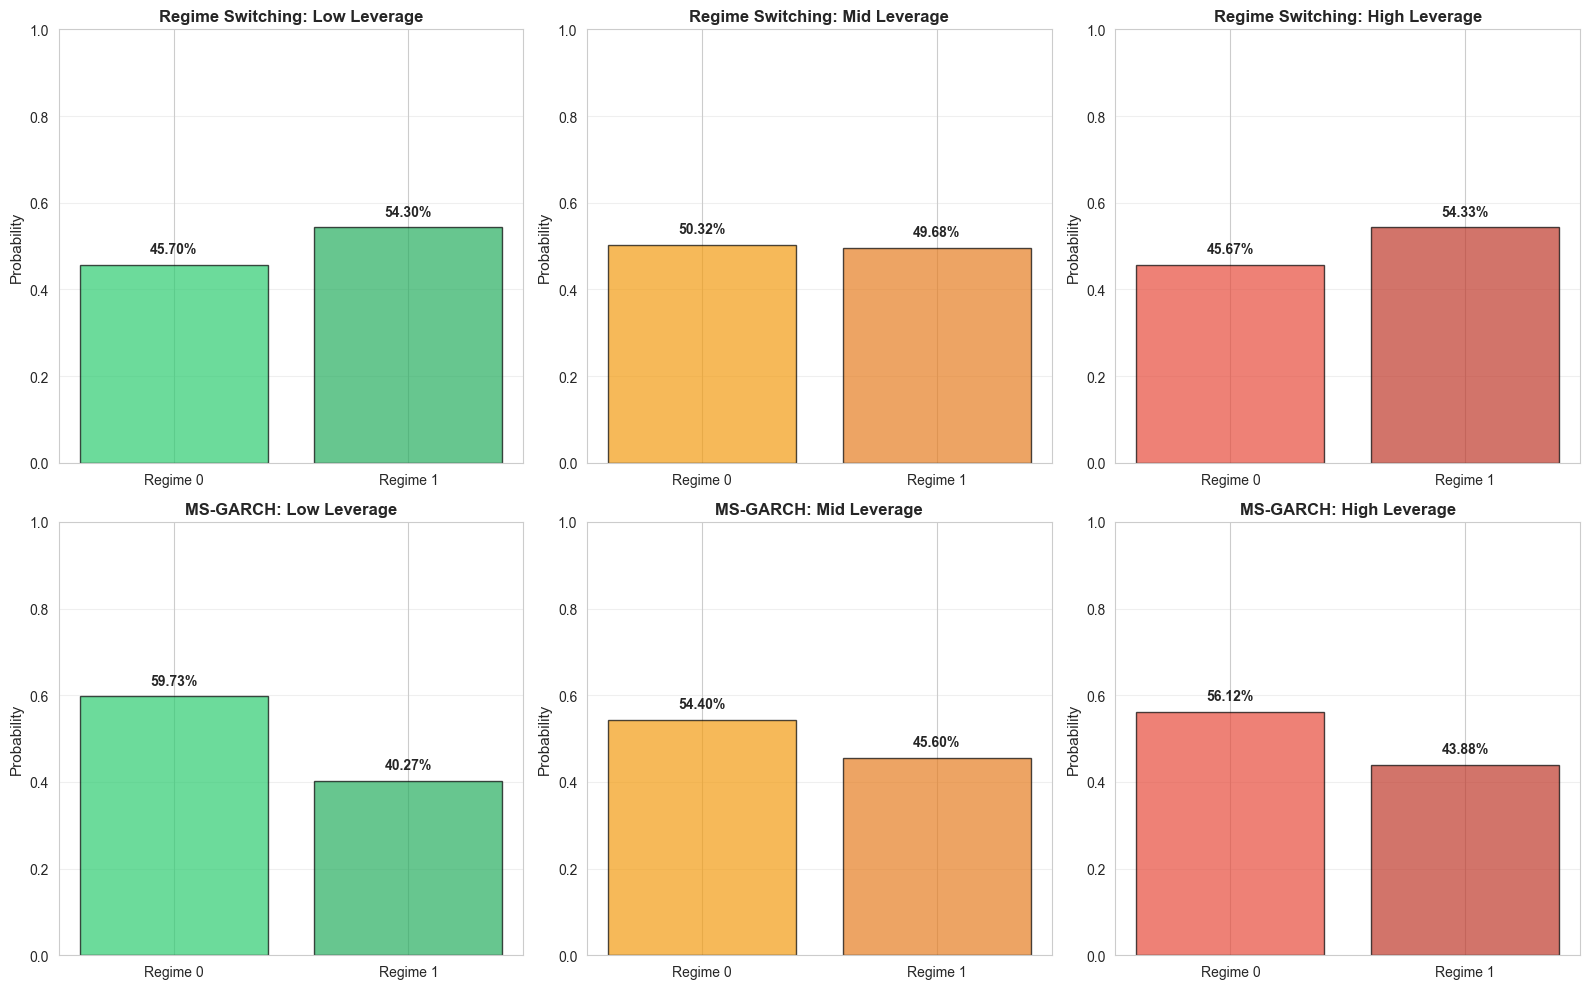

In [ ]:
# Visualize regime frequency by leverage group
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

leverage_groups = ['Low Leverage', 'Mid Leverage', 'High Leverage']
colors_r0 = ['#2ecc71', '#f39c12', '#e74c3c']  # Green, Orange, Red
colors_r1 = ['#27ae60', '#e67e22', '#c0392b']  # Darker shades

# Regime Switching
for idx, leverage_group in enumerate(leverage_groups):
    ax = axes[0, idx]
    group_data = rs_params[rs_params['leverage_tercile'] == leverage_group]
    
    regime_probs = [
        group_data['steady_state_regime_0'].mean(),
        group_data['steady_state_regime_1'].mean()
    ]
    
    bars = ax.bar(['Regime 0', 'Regime 1'], regime_probs, 
                   color=[colors_r0[idx], colors_r1[idx]], alpha=0.7, edgecolor='black')
    ax.set_ylabel('Probability', fontsize=11)
    ax.set_title(f'Regime Switching: {leverage_group}', fontsize=12, fontweight='bold')
    ax.set_ylim([0, 1])
    
    for i, v in enumerate(regime_probs):
        ax.text(i, v + 0.02, f'{v:.2%}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

# MS-GARCH
for idx, leverage_group in enumerate(leverage_groups):
    ax = axes[1, idx]
    group_data = ms_garch[ms_garch['leverage_tercile'] == leverage_group]
    
    regime_probs = [
        group_data['steady_state_regime_0'].mean(),
        group_data['steady_state_regime_1'].mean()
    ]
    
    bars = ax.bar(['Regime 0', 'Regime 1'], regime_probs, 
                   color=[colors_r0[idx], colors_r1[idx]], alpha=0.7, edgecolor='black')
    ax.set_ylabel('Probability', fontsize=11)
    ax.set_title(f'MS-GARCH: {leverage_group}', fontsize=12, fontweight='bold')
    ax.set_ylim([0, 1])
    
    for i, v in enumerate(regime_probs):
        ax.text(i, v + 0.02, f'{v:.2%}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [ ]:
# Parameter comparison by leverage group - Regime Switching
print('='*80)
print('REGIME SWITCHING: PARAMETER COMPARISON BY LEVERAGE GROUP')
print('='*80)

rs_leverage_summary = []

for leverage_group in ['Low Leverage', 'Mid Leverage', 'High Leverage']:
    group_data = rs_params[rs_params['leverage_tercile'] == leverage_group]
    
    rs_leverage_summary.append({
        'Leverage Group': leverage_group,
        'Mean R0 (%)': group_data['regime_0_mean'].mean() * 100,
        'Mean R1 (%)': group_data['regime_1_mean'].mean() * 100,
        'Vol R0 (%)': group_data['regime_0_vol'].mean() * 100,
        'Vol R1 (%)': group_data['regime_1_vol'].mean() * 100,
        'Vol Ratio': group_data['regime_1_vol'].mean() / group_data['regime_0_vol'].mean(),
        'Duration R0': group_data['duration_regime_0'].mean(),
        'Duration R1': group_data['duration_regime_1'].mean(),
        'P(R0)': group_data['steady_state_regime_0'].mean(),
        'P(R1)': group_data['steady_state_regime_1'].mean()
    })

rs_leverage_df = pd.DataFrame(rs_leverage_summary)
display(rs_leverage_df.round(4))

REGIME SWITCHING: PARAMETER COMPARISON BY LEVERAGE GROUP


,Leverage Group,Mean R0 (%),Mean R1 (%),Vol R0 (%),Vol R1 (%),Vol Ratio,Duration R0,Duration R1,P(R0),P(R1)
0,Low Leverage,0.6290,0.2565,0.6854,1.7044,2.4867,36.1245,77.2933,0.4570,0.5430
1,Mid Leverage,0.1102,-0.0195,0.5449,1.3938,2.5578,37.1156,53.2349,0.5032,0.4968
2,High Leverage,-0.7211,-3.4510,0.6817,2.1973,3.2231,105.9738,250.1239,0.4567,0.5433


In [ ]:
# Parameter comparison by leverage group - MS-GARCH (with robust unconditional vol)
print('='*80)
print('MS-GARCH: PARAMETER COMPARISON BY LEVERAGE GROUP')
print('='*80)

ms_leverage_summary = []

for leverage_group in ['Low Leverage', 'Mid Leverage', 'High Leverage']:
    group_data = ms_garch[ms_garch['leverage_tercile'] == leverage_group]
    n = len(group_data)
    
    ms_leverage_summary.append({
        'Leverage Group': leverage_group,
        'Mean R0 (%)': group_data['mu_0'].mean() * 100,
        'Mean R1 (%)': group_data['mu_1'].mean() * 100,
        'Omega R0': group_data['omega_0'].mean(),
        'Omega R1': group_data['omega_1'].mean(),
        'Alpha R0': group_data['alpha_0'].mean(),
        'Alpha R1': group_data['alpha_1'].mean(),
        'Beta R0': group_data['beta_0'].mean(),
        'Beta R1': group_data['beta_1'].mean(),
        'Persist R0': group_data['persist_0'].mean(),
        'Persist R1': group_data['persist_1'].mean(),
        'Uncond Vol R0 (%)': trimmed_mean(group_data['uncond_vol_0']) * 100,
        'Uncond Vol R1 (%)': trimmed_mean(group_data['uncond_vol_1']) * 100,
        '% near-IGARCH R1': (group_data['persist_1'] >= 0.999).sum() / n * 100,
        'Duration R0': group_data['duration_regime_0'].mean(),
        'Duration R1': group_data['duration_regime_1'].mean(),
        'P(R0)': group_data['steady_state_regime_0'].mean(),
        'P(R1)': group_data['steady_state_regime_1'].mean()
    })

ms_leverage_df = pd.DataFrame(ms_leverage_summary)
display(ms_leverage_df.round(6))

MS-GARCH: PARAMETER COMPARISON BY LEVERAGE GROUP


,Leverage Group,Mean R0 (%),Mean R1 (%),Omega R0,Omega R1,Alpha R0,Alpha R1,Beta R0,Beta R1,Persist R0,Persist R1,Uncond Vol R0 (%),Uncond Vol R1 (%),% near-IGARCH R1,Duration R0,Duration R1,P(R0),P(R1)
0,Low Leverage,-0.001088,-0.143044,0.000050,0.000420,0.052147,0.154187,0.754175,0.670625,0.806322,0.824812,95.546558,409.868951,0.0,47.433128,26.463915,0.597304,0.402696
1,Mid Leverage,0.034971,0.014650,0.000033,0.000342,0.073545,0.186378,0.706593,0.630628,0.780138,0.817006,71.792204,306.066723,0.0,42.408129,31.488486,0.543998,0.456002
2,High Leverage,-1.417775,-1.468634,0.000143,0.000834,0.082230,0.172147,0.701718,0.652009,0.783948,0.824156,72.198242,527.444168,0.0,43.338044,32.302190,0.561214,0.438786


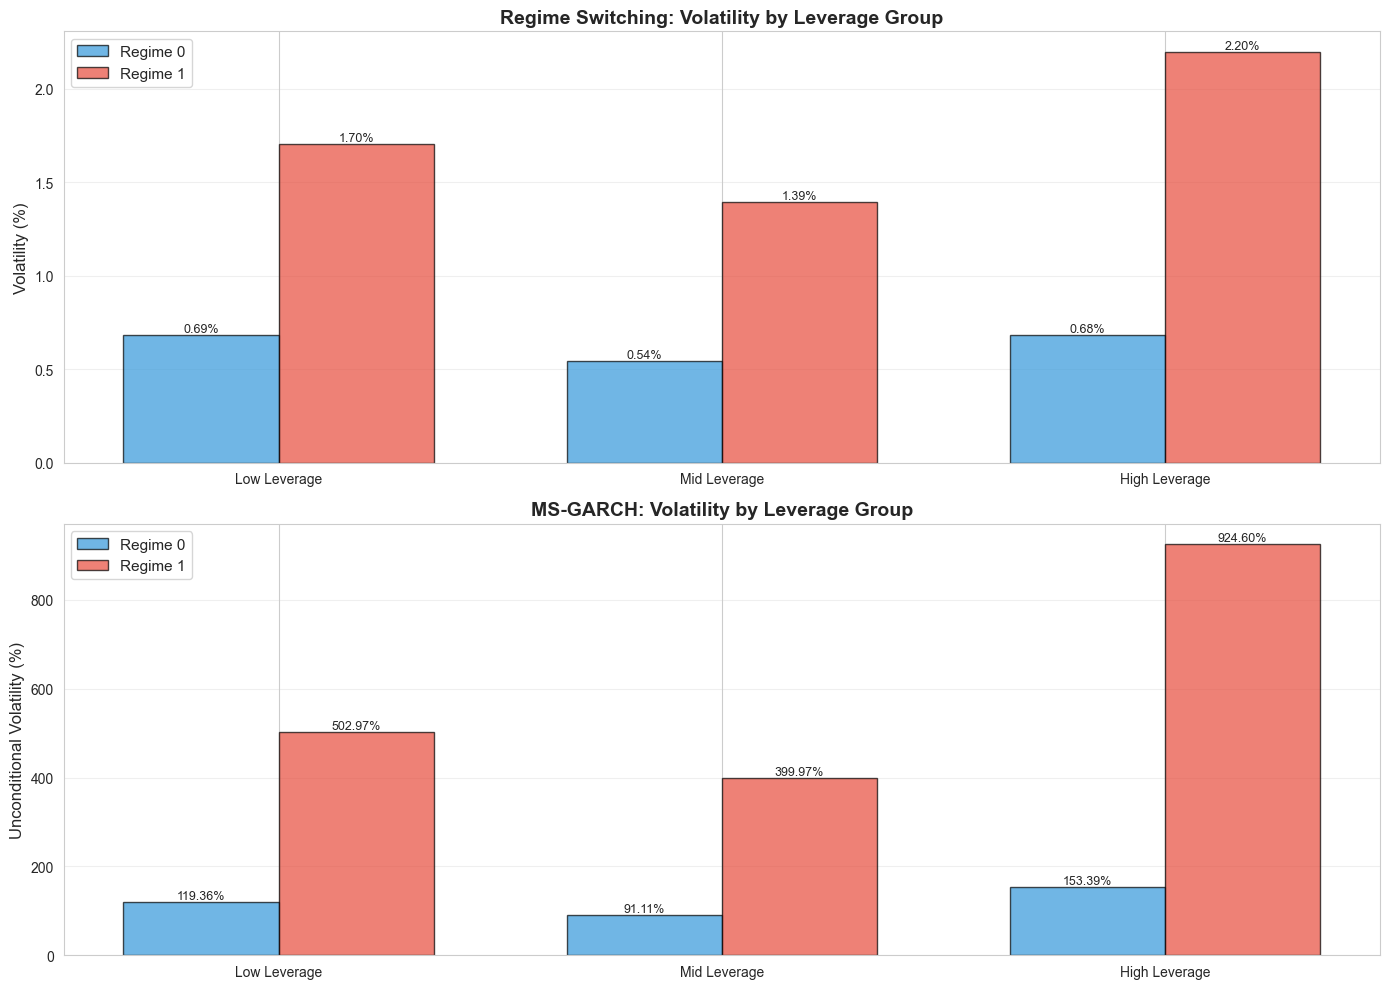

In [ ]:
# Visualize volatility by leverage group
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

leverage_groups = ['Low Leverage', 'Mid Leverage', 'High Leverage']
colors = ['#2ecc71', '#f39c12', '#e74c3c']

# Regime Switching
ax = axes[0]
x = np.arange(len(leverage_groups))
width = 0.35

r0_vols = [rs_params[rs_params['leverage_tercile'] == lg]['regime_0_vol'].mean() * 100 
           for lg in leverage_groups]
r1_vols = [rs_params[rs_params['leverage_tercile'] == lg]['regime_1_vol'].mean() * 100 
           for lg in leverage_groups]

bars1 = ax.bar(x - width/2, r0_vols, width, label='Regime 0', color='#3498db', alpha=0.7, edgecolor='black')
bars2 = ax.bar(x + width/2, r1_vols, width, label='Regime 1', color='#e74c3c', alpha=0.7, edgecolor='black')

ax.set_ylabel('Volatility (%)', fontsize=12)
ax.set_title('Regime Switching: Volatility by Leverage Group', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(leverage_groups)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}%', ha='center', va='bottom', fontsize=9)

# MS-GARCH
ax = axes[1]
r0_vols_ms = [ms_garch[ms_garch['leverage_tercile'] == lg]['uncond_vol_0'].mean() * 100 
              for lg in leverage_groups]
r1_vols_ms = [ms_garch[ms_garch['leverage_tercile'] == lg]['uncond_vol_1'].mean() * 100 
              for lg in leverage_groups]

bars1 = ax.bar(x - width/2, r0_vols_ms, width, label='Regime 0', color='#3498db', alpha=0.7, edgecolor='black')
bars2 = ax.bar(x + width/2, r1_vols_ms, width, label='Regime 1', color='#e74c3c', alpha=0.7, edgecolor='black')

ax.set_ylabel('Unconditional Volatility (%)', fontsize=12)
ax.set_title('MS-GARCH: Volatility by Leverage Group', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(leverage_groups)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

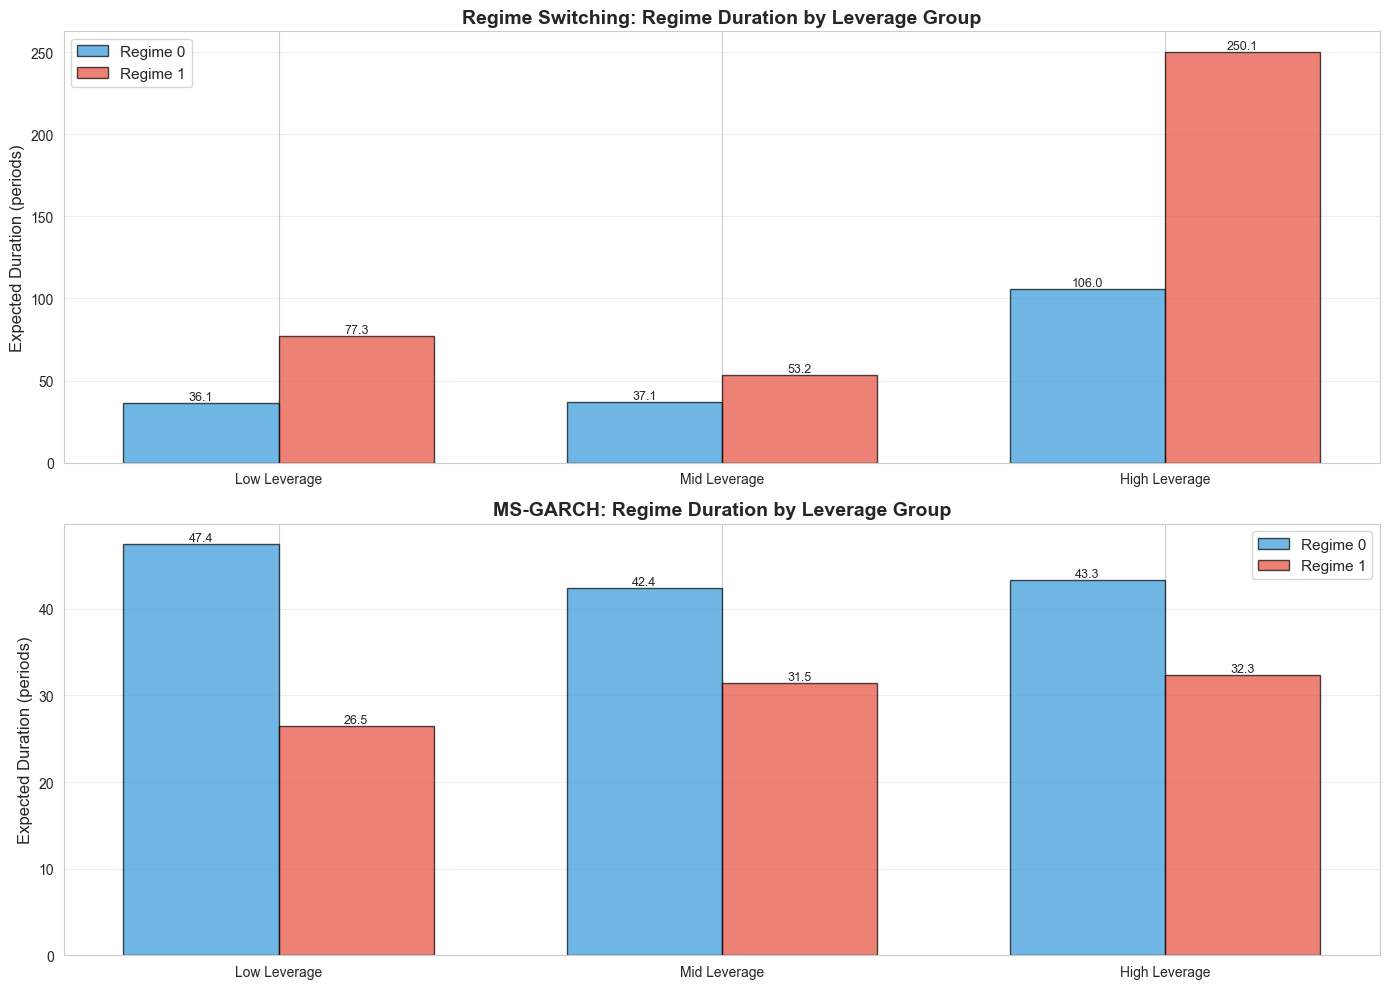

In [ ]:
# Visualize regime duration by leverage group
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

leverage_groups = ['Low Leverage', 'Mid Leverage', 'High Leverage']
x = np.arange(len(leverage_groups))
width = 0.35

# Regime Switching
ax = axes[0]
r0_durations = [rs_params[rs_params['leverage_tercile'] == lg]['duration_regime_0'].mean() 
                for lg in leverage_groups]
r1_durations = [rs_params[rs_params['leverage_tercile'] == lg]['duration_regime_1'].mean() 
                for lg in leverage_groups]

bars1 = ax.bar(x - width/2, r0_durations, width, label='Regime 0', color='#3498db', alpha=0.7, edgecolor='black')
bars2 = ax.bar(x + width/2, r1_durations, width, label='Regime 1', color='#e74c3c', alpha=0.7, edgecolor='black')

ax.set_ylabel('Expected Duration (periods)', fontsize=12)
ax.set_title('Regime Switching: Regime Duration by Leverage Group', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(leverage_groups)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}', ha='center', va='bottom', fontsize=9)

# MS-GARCH
ax = axes[1]
r0_durations_ms = [ms_garch[ms_garch['leverage_tercile'] == lg]['duration_regime_0'].mean() 
                   for lg in leverage_groups]
r1_durations_ms = [ms_garch[ms_garch['leverage_tercile'] == lg]['duration_regime_1'].mean() 
                   for lg in leverage_groups]

bars1 = ax.bar(x - width/2, r0_durations_ms, width, label='Regime 0', color='#3498db', alpha=0.7, edgecolor='black')
bars2 = ax.bar(x + width/2, r1_durations_ms, width, label='Regime 1', color='#e74c3c', alpha=0.7, edgecolor='black')

ax.set_ylabel('Expected Duration (periods)', fontsize=12)
ax.set_title('MS-GARCH: Regime Duration by Leverage Group', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(leverage_groups)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

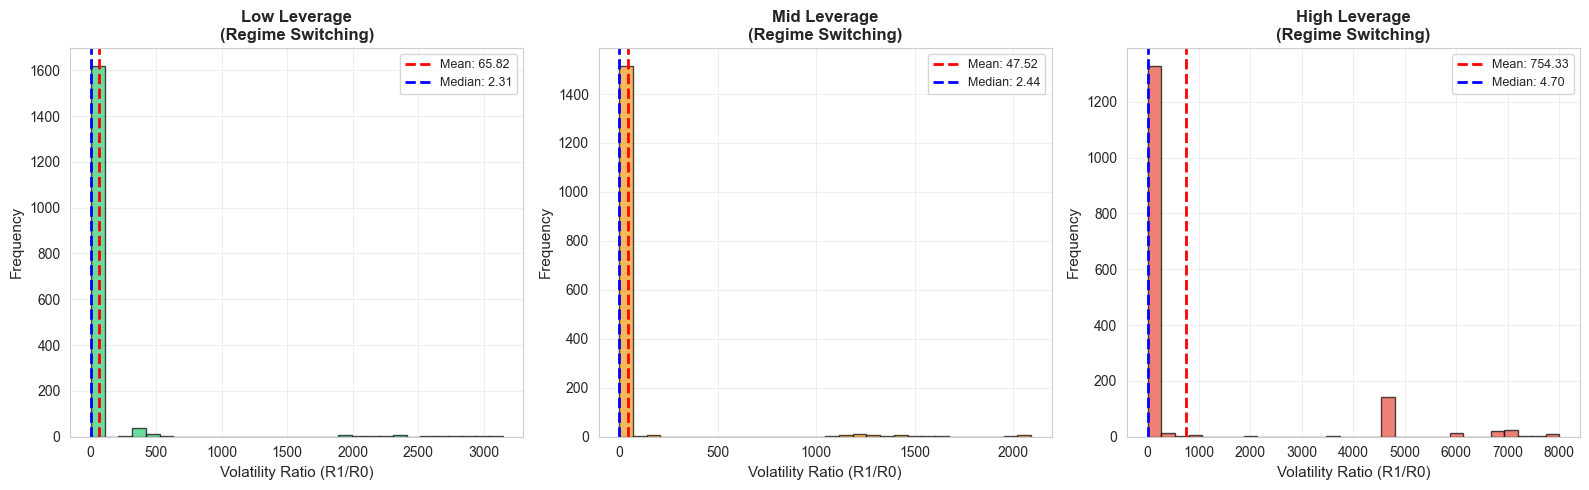

Volatility Ratio Summary by Leverage Group (Regime Switching):

Low Leverage:
  Mean:   65.8214
  Median: 2.3071
  Std:    355.6305
  Min:    1.0019
  Max:    3146.7660

Mid Leverage:
  Mean:   47.5196
  Median: 2.4419
  Std:    251.8153
  Min:    1.0038
  Max:    2090.5542

High Leverage:
  Mean:   754.3302
  Median: 4.6953
  Std:    1892.7280
  Min:    1.0069
  Max:    8003.5009


In [ ]:
# Distribution of volatility ratios by leverage group
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

leverage_groups = ['Low Leverage', 'Mid Leverage', 'High Leverage']
colors = ['#2ecc71', '#f39c12', '#e74c3c']

for idx, leverage_group in enumerate(leverage_groups):
    ax = axes[idx]
    
    # Get volatility ratio for this group (Regime Switching)
    group_data = rs_params[rs_params['leverage_tercile'] == leverage_group]
    vol_ratios = group_data['regime_1_vol'] / group_data['regime_0_vol']
    
    ax.hist(vol_ratios, bins=30, color=colors[idx], alpha=0.7, edgecolor='black')
    ax.axvline(vol_ratios.mean(), color='red', linestyle='--', linewidth=2, 
               label=f'Mean: {vol_ratios.mean():.2f}')
    ax.axvline(vol_ratios.median(), color='blue', linestyle='--', linewidth=2, 
               label=f'Median: {vol_ratios.median():.2f}')
    
    ax.set_xlabel('Volatility Ratio (R1/R0)', fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.set_title(f'{leverage_group}\n(Regime Switching)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print('Volatility Ratio Summary by Leverage Group (Regime Switching):')
print('='*80)
for leverage_group in leverage_groups:
    group_data = rs_params[rs_params['leverage_tercile'] == leverage_group]
    vol_ratios = group_data['regime_1_vol'] / group_data['regime_0_vol']
    
    print(f"\n{leverage_group}:")
    print(f"  Mean:   {vol_ratios.mean():.4f}")
    print(f"  Median: {vol_ratios.median():.4f}")
    print(f"  Std:    {vol_ratios.std():.4f}")
    print(f"  Min:    {vol_ratios.min():.4f}")
    print(f"  Max:    {vol_ratios.max():.4f}")

In [ ]:
# Summary of leverage group findings
print('='*80)
print('LEVERAGE GROUP ANALYSIS - KEY FINDINGS')
print('='*80)

print('\n1. REGIME FREQUENCY BY LEVERAGE:')
for leverage_group in ['Low Leverage', 'Mid Leverage', 'High Leverage']:
    rs_group = rs_params[rs_params['leverage_tercile'] == leverage_group]
    ms_group = ms_garch[ms_garch['leverage_tercile'] == leverage_group]
    
    print(f"\n  {leverage_group}:")
    print(f"    RS - Regime 0: {rs_group['steady_state_regime_0'].mean():.2%}, Regime 1: {rs_group['steady_state_regime_1'].mean():.2%}")
    print(f"    MS - Regime 0: {ms_group['steady_state_regime_0'].mean():.2%}, Regime 1: {ms_group['steady_state_regime_1'].mean():.2%}")

print('\n2. VOLATILITY PATTERNS:')
for leverage_group in ['Low Leverage', 'Mid Leverage', 'High Leverage']:
    rs_group = rs_params[rs_params['leverage_tercile'] == leverage_group]
    vol_ratio = rs_group['regime_1_vol'].mean() / rs_group['regime_0_vol'].mean()
    
    print(f"\n  {leverage_group}:")
    print(f"    Regime 0 Vol: {rs_group['regime_0_vol'].mean()*100:.2f}%")
    print(f"    Regime 1 Vol: {rs_group['regime_1_vol'].mean()*100:.2f}%")
    print(f"    Volatility Ratio: {vol_ratio:.2f}x")

print('\n3. REGIME PERSISTENCE:')
for leverage_group in ['Low Leverage', 'Mid Leverage', 'High Leverage']:
    rs_group = rs_params[rs_params['leverage_tercile'] == leverage_group]
    
    print(f"\n  {leverage_group}:")
    print(f"    Regime 0 Duration: {rs_group['duration_regime_0'].mean():.1f} periods")
    print(f"    Regime 1 Duration: {rs_group['duration_regime_1'].mean():.1f} periods")

print('\n4. INTERPRETATION:')
print('  - High leverage firms may show different regime dynamics')
print('  - Volatility patterns may vary by capital structure')
print('  - Regime persistence could differ across leverage groups')
print('  - Consider leverage when interpreting regime-switching behavior')

print('\n' + '='*80)

LEVERAGE GROUP ANALYSIS - KEY FINDINGS

1. REGIME FREQUENCY BY LEVERAGE:

  Low Leverage:
    RS - Regime 0: 45.70%, Regime 1: 54.30%
    MS - Regime 0: 59.73%, Regime 1: 40.27%

  Mid Leverage:
    RS - Regime 0: 50.32%, Regime 1: 49.68%
    MS - Regime 0: 54.40%, Regime 1: 45.60%

  High Leverage:
    RS - Regime 0: 45.67%, Regime 1: 54.33%
    MS - Regime 0: 56.12%, Regime 1: 43.88%

2. VOLATILITY PATTERNS:

  Low Leverage:
    Regime 0 Vol: 0.69%
    Regime 1 Vol: 1.70%
    Volatility Ratio: 2.49x

  Mid Leverage:
    Regime 0 Vol: 0.54%
    Regime 1 Vol: 1.39%
    Volatility Ratio: 2.56x

  High Leverage:
    Regime 0 Vol: 0.68%
    Regime 1 Vol: 2.20%
    Volatility Ratio: 3.22x

3. REGIME PERSISTENCE:

  Low Leverage:
    Regime 0 Duration: 36.1 periods
    Regime 1 Duration: 77.3 periods

  Mid Leverage:
    Regime 0 Duration: 37.1 periods
    Regime 1 Duration: 53.2 periods

  High Leverage:
    Regime 0 Duration: 106.0 periods
    Regime 1 Duration: 250.1 periods

4. INTERPRE

## 12. MS-GARCH: GARCH Dynamics per Regime

Deep-dive into the regime-specific GARCH(1,1) parameters.

We extract **derived metrics** (persistence, unconditional volatility, half-life of
shocks, stationarity) and produce four diagnostic plots:
1. Parameter comparison bar chart
2. Persistence & unconditional volatility
3. News Impact Curves
4. Volatility Impulse Response

MS-GARCH  —  DERIVED PER-REGIME METRICS
          omega    alpha     beta        nu  persistence  stationary  uncond_vol  half_life   p_stay  steady_state  expected_duration
regime                                                                                                                               
0      0.000075 0.068802 0.721809 16.065246     0.790612        True    0.007713   2.950215 0.901804      0.546148          10.183672
1      0.000528 0.170412 0.651662  4.359901     0.822074        True    0.038554   3.537829 0.881834      0.453852           8.462688



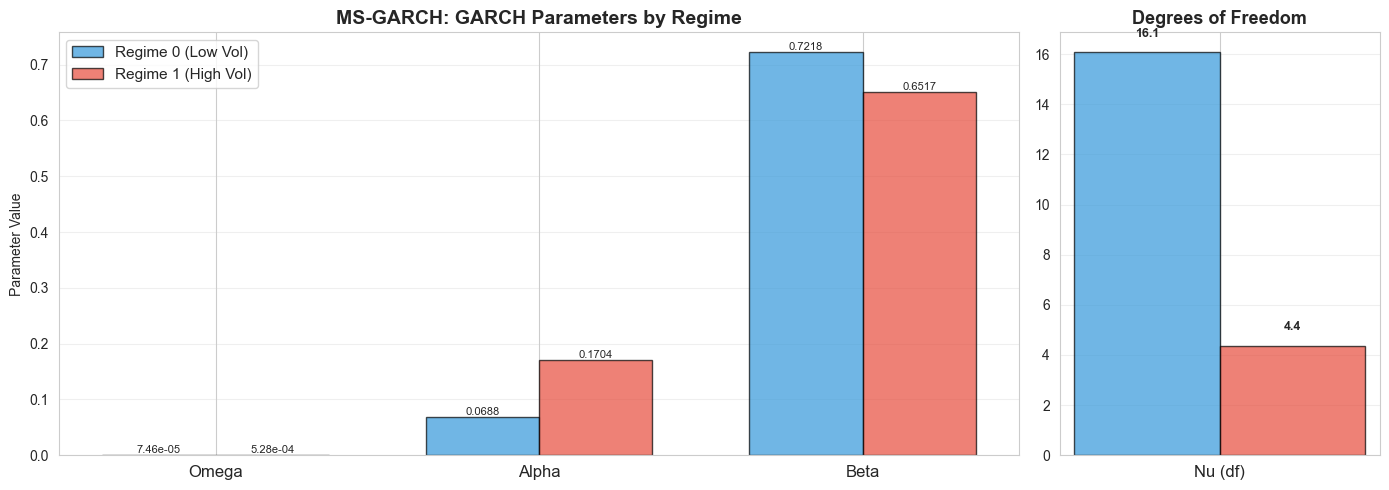

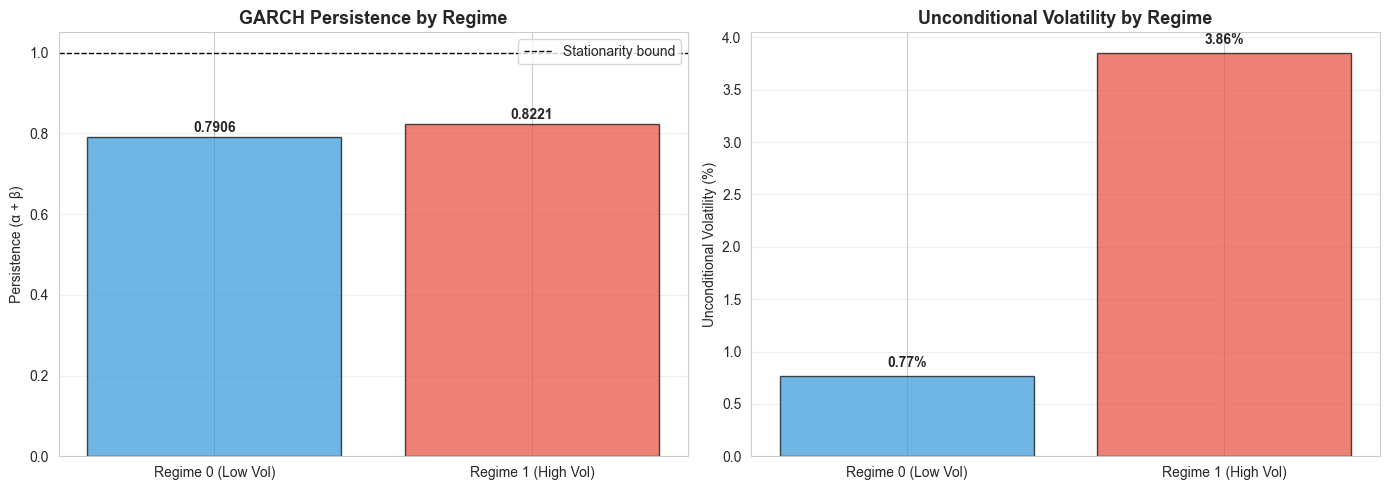

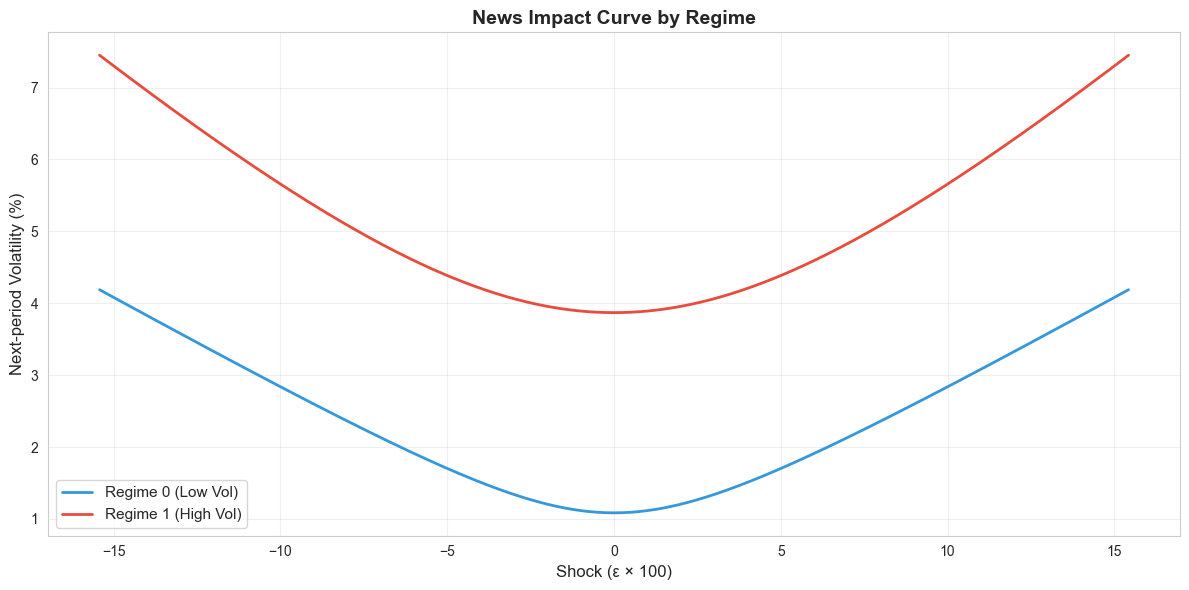

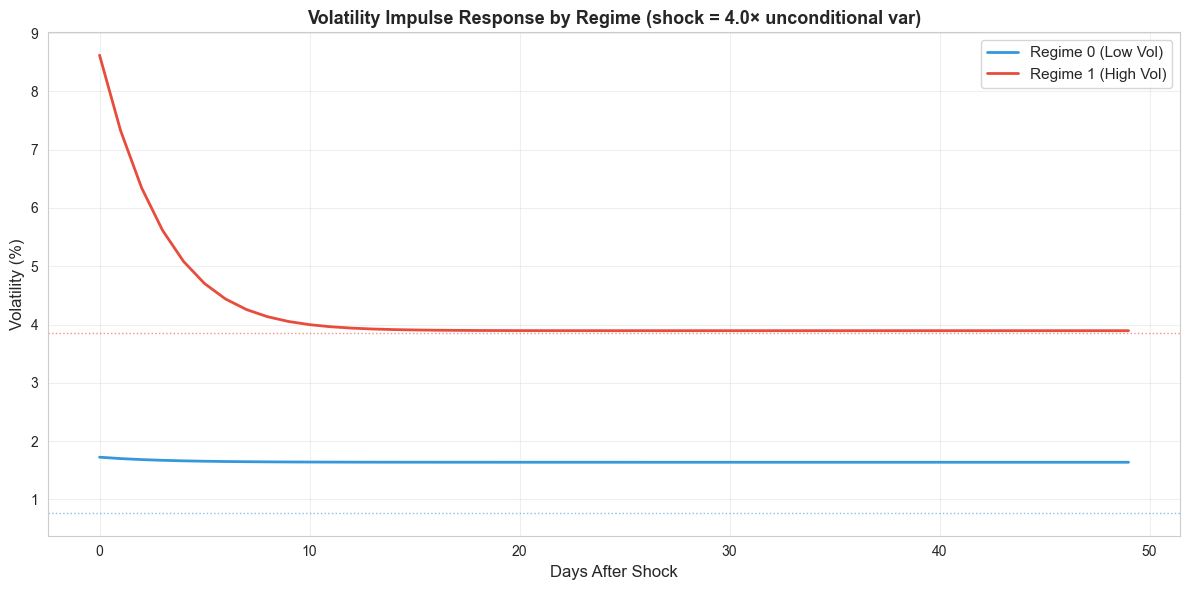

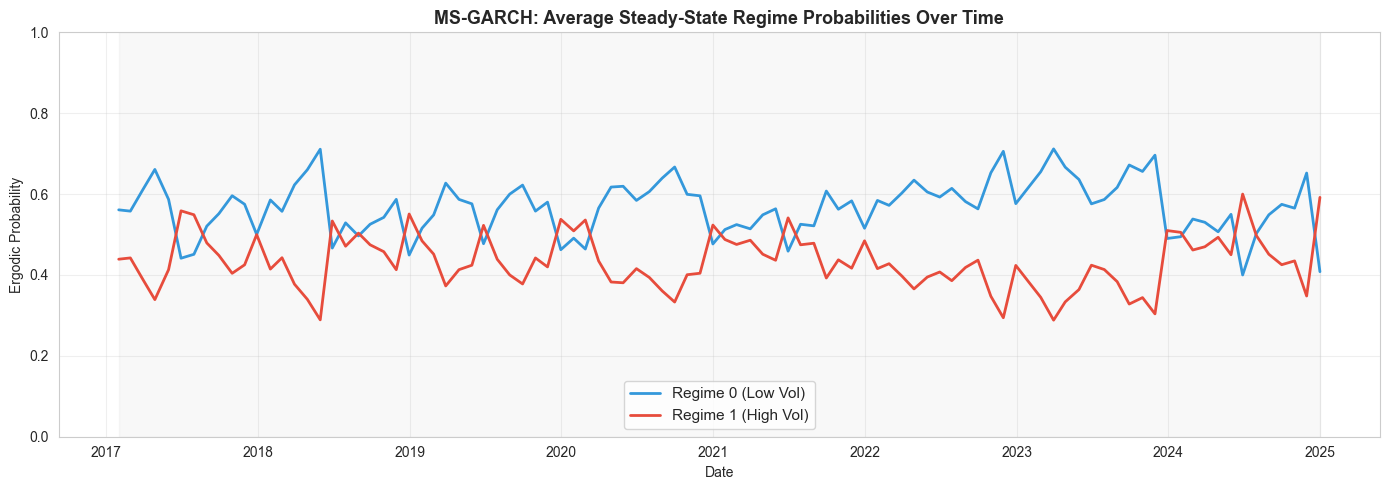

In [ ]:
import sys
import importlib
from pathlib import Path

# Ensure project root (the folder that contains src/) is on sys.path
if 'PROJECT_ROOT' in globals():
    project_root = Path(PROJECT_ROOT)
else:
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd / 'Seminar QF', cwd.parent]
    project_root = None
    for candidate in candidates:
        if (candidate / 'src').exists():
            project_root = candidate
            break
    if project_root is None:
        tried = '\n'.join(str(c / 'src') for c in candidates)
        raise ModuleNotFoundError(f'Could not locate project root containing src/. Tried:\n{tried}')

project_root_str = str(project_root)
if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

# Import (or reload) the analysis module
import src.analysis.regime_analysis as ra
importlib.reload(ra)

# Run the full analysis - prints metrics table + generates all plots
ms_garch_metrics = ra.run_ms_garch_analysis(ms_garch, verbose=True)

## 13. MS-GARCH: Alpha, Beta & Persistence Over Time

**Plot 1** — cross-sectional **median** of α, β and α+β for each regime over time (6 lines).  
**Plot 2** — same three metrics for a **single firm** (uses the same `sample_gvkey` selected in Section 8).

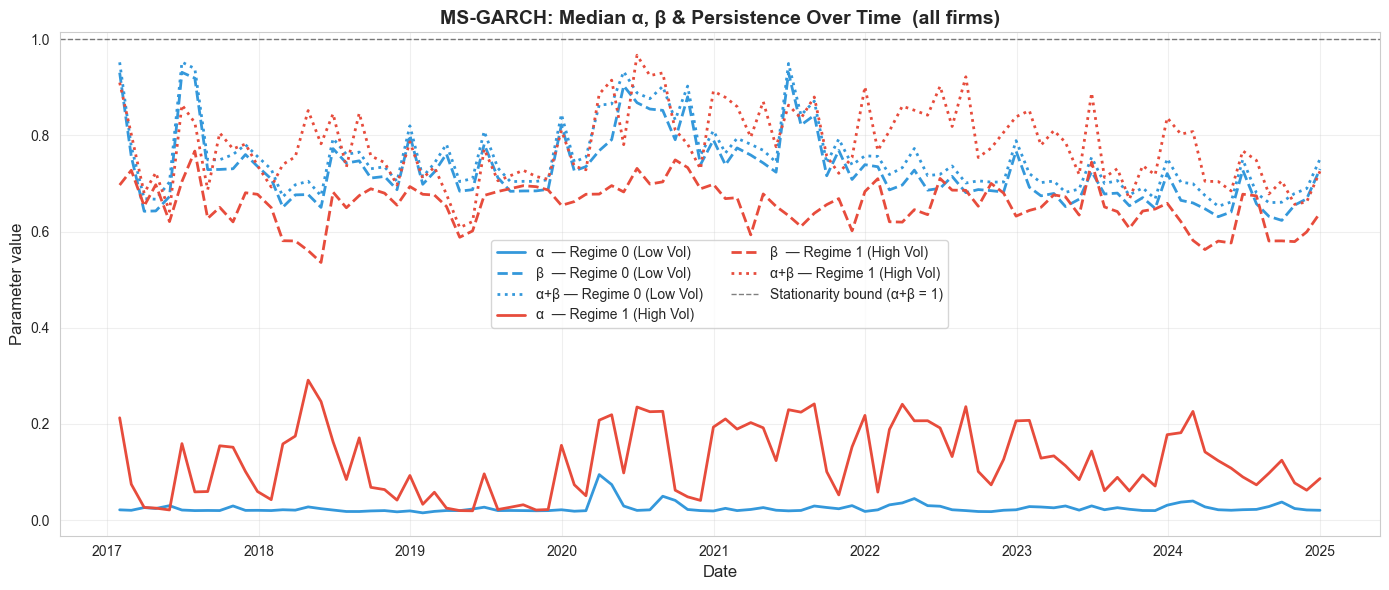

In [ ]:
# ── Plot 1: Cross-sectional median α, β, persistence per regime — one graph ──

ts_median = ms_garch.groupby('date').agg(
    alpha_0=('alpha_0', 'median'),
    alpha_1=('alpha_1', 'median'),
    beta_0=('beta_0',  'median'),
    beta_1=('beta_1',  'median'),
)
ts_median['persistence_0'] = ts_median['alpha_0'] + ts_median['beta_0']
ts_median['persistence_1'] = ts_median['alpha_1'] + ts_median['beta_1']

fig, ax = plt.subplots(figsize=(14, 6))

# Regime 0 lines (blue shades)
ax.plot(ts_median.index, ts_median['alpha_0'],       color='#3498db', linewidth=2, linestyle='-',  label='α  — Regime 0 (Low Vol)')
ax.plot(ts_median.index, ts_median['beta_0'],        color='#3498db', linewidth=2, linestyle='--', label='β  — Regime 0 (Low Vol)')
ax.plot(ts_median.index, ts_median['persistence_0'], color='#3498db', linewidth=2, linestyle=':',  label='α+β — Regime 0 (Low Vol)')

# Regime 1 lines (red shades)
ax.plot(ts_median.index, ts_median['alpha_1'],       color='#e74c3c', linewidth=2, linestyle='-',  label='α  — Regime 1 (High Vol)')
ax.plot(ts_median.index, ts_median['beta_1'],        color='#e74c3c', linewidth=2, linestyle='--', label='β  — Regime 1 (High Vol)')
ax.plot(ts_median.index, ts_median['persistence_1'], color='#e74c3c', linewidth=2, linestyle=':',  label='α+β — Regime 1 (High Vol)')

ax.axhline(1.0, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Stationarity bound (α+β = 1)')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Parameter value', fontsize=12)
ax.set_title('MS-GARCH: Median α, β & Persistence Over Time  (all firms)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ── Firm selector ─────────────────────────────────────────────────────────────
# Change `selected_gvkey` to any gvkey present in ms_garch, then re-run this
# cell and the plot cell below.

available_gvkeys = sorted(ms_garch['gvkey'].unique())
print(f"Total firms available: {len(available_gvkeys)}")
print(f"First 20 gvkeys: {available_gvkeys[:20]}")

# ── Set your firm here ────────────────────────────────────────────────────────
selected_gvkey = 241456   # <-- change this value

# Validate
if selected_gvkey not in available_gvkeys:
    raise ValueError(f"gvkey {selected_gvkey} not found. Choose from available_gvkeys list above.")

firm_ts = (ms_garch[ms_garch['gvkey'] == selected_gvkey]
           [['date', 'alpha_0', 'beta_0', 'alpha_1', 'beta_1']]
           .sort_values('date')
           .copy())
firm_ts['persistence_0'] = firm_ts['alpha_0'] + firm_ts['beta_0']
firm_ts['persistence_1'] = firm_ts['alpha_1'] + firm_ts['beta_1']

n_obs = len(firm_ts)
date_range = f"{firm_ts['date'].min().strftime('%Y-%m')} → {firm_ts['date'].max().strftime('%Y-%m')}"
print(f"\nSelected firm  : gvkey = {selected_gvkey}")
print(f"Observations   : {n_obs} windows")
print(f"Date range     : {date_range}")
print(f"\nParameter summary:")
print(firm_ts[['alpha_0','beta_0','persistence_0','alpha_1','beta_1','persistence_1']].describe().round(4))

Total firms available: 34
First 20 gvkeys: [np.int64(14447), np.int64(15532), np.int64(15549), np.int64(15617), np.int64(15677), np.int64(15724), np.int64(16348), np.int64(17436), np.int64(17452), np.int64(19349), np.int64(23667), np.int64(23671), np.int64(24625), np.int64(61616), np.int64(63120), np.int64(100022), np.int64(100080), np.int64(100581), np.int64(100957), np.int64(101202)]

Selected firm  : gvkey = 241456
Observations   : 96 windows
Date range     : 2017-01 → 2024-12

Parameter summary:
       alpha_0   beta_0  persistence_0  alpha_1   beta_1  persistence_1
count  96.0000  96.0000        96.0000  96.0000  96.0000        96.0000
mean    0.0548   0.7456         0.8004   0.1150   0.7126         0.8276
std     0.0961   0.1772         0.1245   0.1547   0.2003         0.1287
min     0.0100   0.3000         0.6000   0.0100   0.3000         0.6000
25%     0.0100   0.6658         0.6943   0.0150   0.5984         0.7051
50%     0.0175   0.7300         0.7578   0.0207   0.7321       

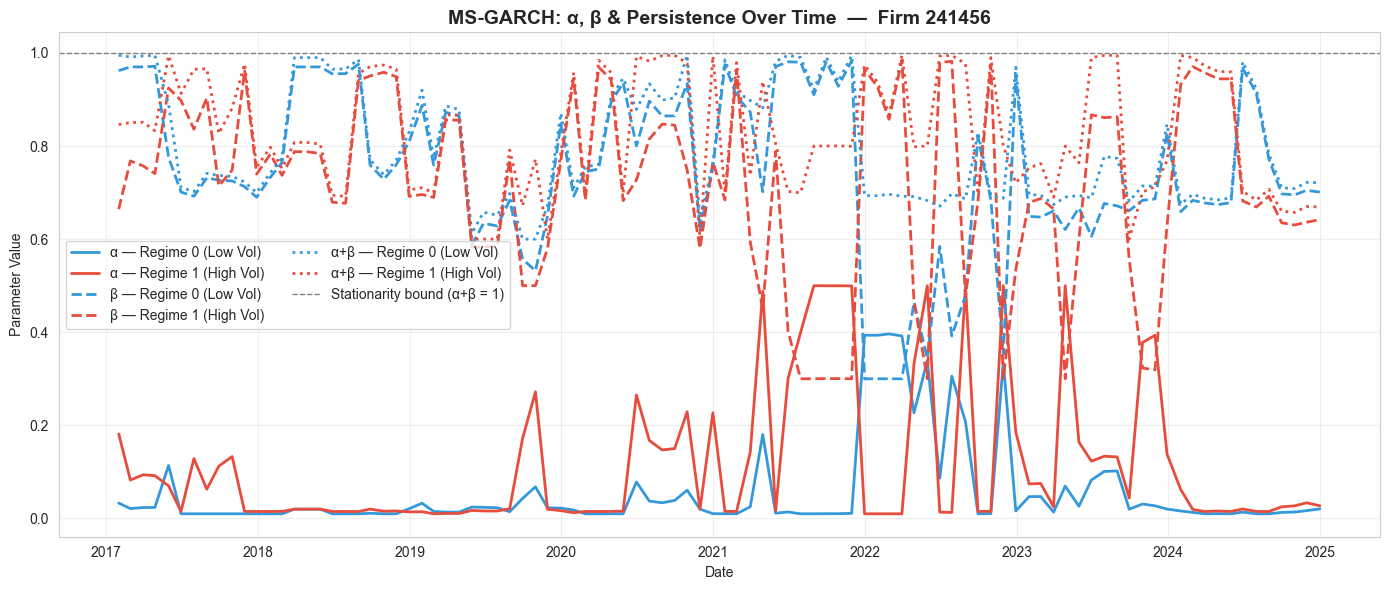

In [ ]:
# ── Plot: α, β, persistence per regime for selected firm ─────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(firm_ts['date'], firm_ts['alpha_0'],       color='#3498db', linestyle='-',  linewidth=2, label='α — Regime 0 (Low Vol)')
ax.plot(firm_ts['date'], firm_ts['alpha_1'],       color='#e74c3c', linestyle='-',  linewidth=2, label='α — Regime 1 (High Vol)')
ax.plot(firm_ts['date'], firm_ts['beta_0'],        color='#3498db', linestyle='--', linewidth=2, label='β — Regime 0 (Low Vol)')
ax.plot(firm_ts['date'], firm_ts['beta_1'],        color='#e74c3c', linestyle='--', linewidth=2, label='β — Regime 1 (High Vol)')
ax.plot(firm_ts['date'], firm_ts['persistence_0'], color='#3498db', linestyle=':',  linewidth=2, label='α+β — Regime 0 (Low Vol)')
ax.plot(firm_ts['date'], firm_ts['persistence_1'], color='#e74c3c', linestyle=':',  linewidth=2, label='α+β — Regime 1 (High Vol)')
ax.axhline(1.0, color='gray', linestyle='--', linewidth=1, label='Stationarity bound (α+β = 1)')

ax.set_xlabel('Date')
ax.set_ylabel('Parameter Value')
ax.set_title(f'MS-GARCH: α, β & Persistence Over Time  —  Firm {selected_gvkey}', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 14. Filterable Alpha-Beta Scatter (MS-GARCH)


MS-GARCH Scatter Filter Audit:
  Period: ALL
  Year: ALL
  Leverage Group: ALL
  Preview observations: 3,264
  Preview unique firms: 34
  Preview date range: 2017-01-31 to 2024-12-31

Global comparison space (before selectors):
  Rows: 3,264
  Firms: 34
  Periods: ['COVID Shock', 'Post-Recovery', 'Pre-COVID', 'Recovery']
  Years: [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024] ...
  Leverage groups: ['High Leverage', 'Low Leverage', 'Mid Leverage']


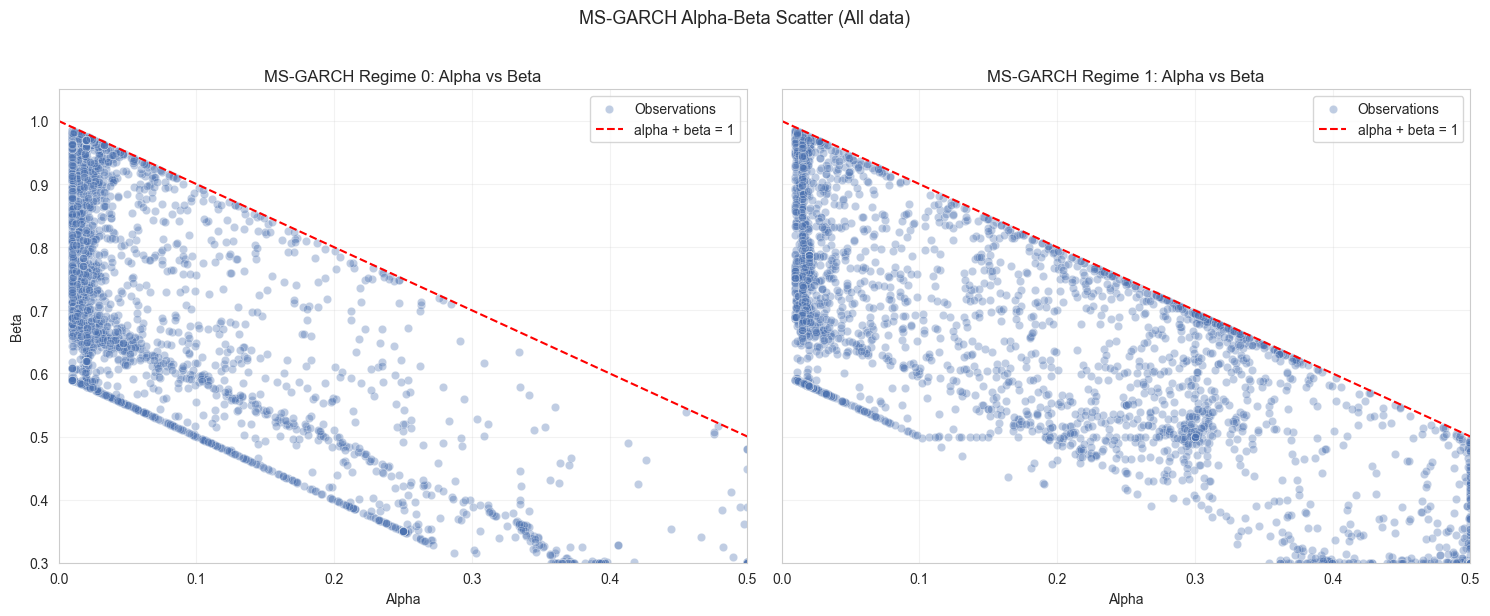


Exported 24 scatter plot files to: C:\Users\Chase\Downloads\Seminar QF\Seminar QF\data\output\ms_garch_alpha_beta_scatter_by_filters


In [ ]:
import os
import re
from pathlib import Path

# Runtime selectors (set to None to include all)
SELECT_PERIOD = None  # e.g., 'Pre-COVID', 'COVID Shock', 'Recovery', 'Post-Recovery'
SELECT_YEAR = None  # e.g., 2020
SELECT_LEVERAGE_GROUP = None  # e.g., 'Low Leverage', 'Mid Leverage', 'High Leverage'

# Batch export controls
EXPORT_SCATTERS = True
EXPORT_DIR = str(DATA_OUTPUT / 'ms_garch_alpha_beta_scatter_by_filters')
MAX_POINTS_PER_PLOT = 7000
EXPORT_USE_FILTERED_DATA = False  # False = full comparison map; True = current slice only

PERIOD_RANGES = {
    'Pre-COVID': (None, '2020-02-29'),
    'COVID Shock': ('2020-03-01', '2020-12-31'),
    'Recovery': ('2021-01-01', '2022-12-31'),
    'Post-Recovery': ('2023-01-01', None),
}


def slugify(text):
    return re.sub(r'[^a-z0-9]+', '-', str(text).strip().lower()).strip('-')


def _resolve_existing_path(candidates):
    for candidate in candidates:
        path_obj = Path(candidate)
        if path_obj.exists():
            return str(path_obj)
    return None


def make_filtered_scatter(df_plot, title_suffix, save_path=None, max_points=7000, show_plot=True):
    if df_plot.empty:
        return False

    plot_n = min(max_points, len(df_plot))
    plot_df = df_plot.sample(plot_n, random_state=42) if len(df_plot) > plot_n else df_plot

    fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)

    sns.scatterplot(
        data=plot_df,
        x='alpha_0',
        y='beta_0',
        alpha=0.35,
        color='#4C72B0',
        label='Observations',
        ax=axes[0],
    )
    sns.scatterplot(
        data=plot_df,
        x='alpha_1',
        y='beta_1',
        alpha=0.35,
        color='#4C72B0',
        label='Observations',
        ax=axes[1],
    )

    for ax, panel_title in zip(axes, ['Regime 0', 'Regime 1']):
        ax.plot([0, 1], [1, 0], 'r--', label='alpha + beta = 1')
        ax.set_xlim(0, 0.5)
        ax.set_ylim(0.3, 1.05)
        ax.set_xlabel('Alpha')
        ax.set_ylabel('Beta')
        ax.set_title(f'MS-GARCH {panel_title}: Alpha vs Beta')
        ax.grid(True, alpha=0.25)
        ax.legend(loc='best')

    plt.suptitle(f'MS-GARCH Alpha-Beta Scatter ({title_suffix})', y=1.02, fontsize=13)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    if show_plot:
        plt.show()
    else:
        plt.close(fig)
    return True


ms_scatter = ms_garch.copy()
ms_scatter['date'] = pd.to_datetime(ms_scatter['date'], errors='coerce')

# Ensure leverage groups exist with the same qcut grouping used in paper comparison
if 'leverage_tercile' not in ms_scatter.columns:
    merged_path = _resolve_existing_path([
        str(DATA_OUTPUT / 'merged_data_with_merton.csv'),
        'data/output/merged_data_with_merton.csv',
        '../data/output/merged_data_with_merton.csv',
    ])
    if merged_path is None:
        raise FileNotFoundError('Could not locate merged_data_with_merton.csv for leverage mapping.')

    lev_df = pd.read_csv(merged_path, usecols=['gvkey', 'date', 'liabilities_total', 'asset_value', 'mkt_cap'])
    lev_df['date'] = pd.to_datetime(lev_df['date'], errors='coerce')
    lev_df['leverage_ratio'] = np.where(
        lev_df['asset_value'].gt(0),
        lev_df['liabilities_total'] / lev_df['asset_value'],
        np.where(lev_df['mkt_cap'].gt(0), lev_df['liabilities_total'] / lev_df['mkt_cap'], np.nan),
    )
    lev_df = lev_df[['gvkey', 'date', 'leverage_ratio']].dropna(subset=['gvkey', 'date'])

    map_df = lev_df[['gvkey', 'leverage_ratio']].dropna()
    q = min(3, map_df['leverage_ratio'].nunique())
    if q >= 2:
        labels = ['Low Leverage', 'Mid Leverage', 'High Leverage'][:q]
        map_df['leverage_tercile'] = pd.qcut(
            map_df['leverage_ratio'], q=q, labels=labels, duplicates='drop'
        )
    else:
        map_df['leverage_tercile'] = 'All'

    firm_lev = map_df.groupby('gvkey')['leverage_tercile'].first().astype(str)
    ms_scatter['leverage_tercile'] = ms_scatter['gvkey'].map(firm_lev).fillna('Unknown')
else:
    ms_scatter['leverage_tercile'] = ms_scatter['leverage_tercile'].astype(str).fillna('Unknown')

# Add period and year dimensions
ms_scatter['period'] = 'Unassigned'
for label, (start, end) in PERIOD_RANGES.items():
    mask = pd.Series(True, index=ms_scatter.index)
    if start is not None:
        mask &= ms_scatter['date'] >= pd.Timestamp(start)
    if end is not None:
        mask &= ms_scatter['date'] <= pd.Timestamp(end)
    ms_scatter.loc[mask, 'period'] = label
ms_scatter['year'] = ms_scatter['date'].dt.year.astype('Int64')

ms_scatter = ms_scatter.dropna(subset=['alpha_0', 'beta_0', 'alpha_1', 'beta_1'])
if ms_scatter.empty:
    raise ValueError('No rows remain after preprocessing filters.')

# Save full comparison space
ms_scatter_all = ms_scatter.copy()

# Apply interactive selectors for preview
if SELECT_PERIOD is not None:
    valid_periods = sorted(ms_scatter['period'].dropna().unique())
    if SELECT_PERIOD not in valid_periods:
        raise ValueError(f"Invalid SELECT_PERIOD={SELECT_PERIOD}. Available: {valid_periods}")
    ms_scatter = ms_scatter[ms_scatter['period'] == SELECT_PERIOD].copy()

if SELECT_YEAR is not None:
    valid_years = sorted([int(y) for y in ms_scatter['year'].dropna().unique()])
    if int(SELECT_YEAR) not in valid_years:
        raise ValueError(f"Invalid SELECT_YEAR={SELECT_YEAR}. Available: {valid_years}")
    ms_scatter = ms_scatter[ms_scatter['year'] == int(SELECT_YEAR)].copy()

if SELECT_LEVERAGE_GROUP is not None:
    valid_lev_groups = sorted(ms_scatter['leverage_tercile'].dropna().unique())
    if SELECT_LEVERAGE_GROUP not in valid_lev_groups:
        raise ValueError(
            f"Invalid SELECT_LEVERAGE_GROUP={SELECT_LEVERAGE_GROUP}. Available: {valid_lev_groups}"
        )
    ms_scatter = ms_scatter[ms_scatter['leverage_tercile'] == SELECT_LEVERAGE_GROUP].copy()

if ms_scatter.empty:
    raise ValueError('No rows remain after applying the selected filters.')

print('MS-GARCH Scatter Filter Audit:')
print(f"  Period: {SELECT_PERIOD if SELECT_PERIOD is not None else 'ALL'}")
print(f"  Year: {SELECT_YEAR if SELECT_YEAR is not None else 'ALL'}")
print(f"  Leverage Group: {SELECT_LEVERAGE_GROUP if SELECT_LEVERAGE_GROUP is not None else 'ALL'}")
print(f"  Preview observations: {len(ms_scatter):,}")
print(f"  Preview unique firms: {ms_scatter['gvkey'].nunique():,}")
print(f"  Preview date range: {ms_scatter['date'].min().date()} to {ms_scatter['date'].max().date()}")
print()
print('Global comparison space (before selectors):')
print(f"  Rows: {len(ms_scatter_all):,}")
print(f"  Firms: {ms_scatter_all['gvkey'].nunique():,}")
print(f"  Periods: {sorted(ms_scatter_all['period'].dropna().unique())}")
print(f"  Years: {sorted([int(y) for y in ms_scatter_all['year'].dropna().unique()])[:8]} ...")
print(f"  Leverage groups: {sorted(ms_scatter_all['leverage_tercile'].dropna().unique())}")

# Main filtered plot
display_title = []
if SELECT_PERIOD is not None:
    display_title.append(f"Period={SELECT_PERIOD}")
if SELECT_YEAR is not None:
    display_title.append(f"Year={SELECT_YEAR}")
if SELECT_LEVERAGE_GROUP is not None:
    display_title.append(f"Leverage={SELECT_LEVERAGE_GROUP}")
title_suffix = ', '.join(display_title) if display_title else 'All data'
make_filtered_scatter(ms_scatter, title_suffix=title_suffix, max_points=MAX_POINTS_PER_PLOT, show_plot=True)

if EXPORT_SCATTERS:
    export_base = ms_scatter.copy() if EXPORT_USE_FILTERED_DATA else ms_scatter_all.copy()

    os.makedirs(EXPORT_DIR, exist_ok=True)
    export_count = 0

    def _export_subset(df_subset, filename, title):
        save_path = os.path.join(EXPORT_DIR, filename)
        return make_filtered_scatter(
            df_subset,
            title_suffix=title,
            save_path=save_path,
            max_points=MAX_POINTS_PER_PLOT,
            show_plot=False,
        )

    # 1) Per period
    for period in sorted(export_base['period'].dropna().unique()):
        d = export_base[export_base['period'] == period]
        if d.empty:
            continue
        if _export_subset(d, f"ms_garch_alpha_beta_period_{slugify(period)}.png", f"Period={period}"):
            export_count += 1

    # 2) Per year
    for year in sorted([int(y) for y in export_base['year'].dropna().unique()]):
        d = export_base[export_base['year'] == year]
        if d.empty:
            continue
        if _export_subset(d, f"ms_garch_alpha_beta_year_{year}.png", f"Year={year}"):
            export_count += 1

    # 3) Per period x leverage
    for period in sorted(export_base['period'].dropna().unique()):
        sub = export_base[export_base['period'] == period]
        for lev in sorted(sub['leverage_tercile'].dropna().unique()):
            d = sub[sub['leverage_tercile'] == lev]
            if d.empty:
                continue
            if _export_subset(
                d,
                f"ms_garch_alpha_beta_period_{slugify(period)}_leverage_{slugify(lev)}.png",
                f"Period={period}, Leverage={lev}",
            ):
                export_count += 1

    print(f"\nExported {export_count} scatter plot files to: {EXPORT_DIR}")

## MS-GARCH α–β Scatter by Leverage Group

Same scatter plots as above but with **three panels** (Low Leverage, Mid Leverage, High Leverage) arranged left-to-right in a single figure, each showing Regime 0 and Regime 1.

In [ ]:
# MS-GARCH Alpha-Beta Scatter: 3 panels by Leverage Group (Low → High)
# Each panel contains Regime 0 (left) and Regime 1 (right)

leverage_order = ['Low Leverage', 'Mid Leverage', 'High Leverage']
available_groups = [g for g in leverage_order if g in ms_scatter_all['leverage_tercile'].unique()]
n_groups = len(available_groups)

if n_groups == 0:
    raise ValueError('No leverage groups found in ms_scatter_all.')

MAX_POINTS = 5000  # per leverage group

fig, axes = plt.subplots(
    n_groups, 2,
    figsize=(12, 4.2 * n_groups),
    sharex=True, sharey=True,
    constrained_layout=False,
)
if n_groups == 1:
    axes = axes[np.newaxis, :]  # ensure 2-D

for row_idx, lev_group in enumerate(available_groups):
    subset = ms_scatter_all[ms_scatter_all['leverage_tercile'] == lev_group].copy()
    n_obs = len(subset)
    if n_obs > MAX_POINTS:
        subset = subset.sample(MAX_POINTS, random_state=42)

    # Regime 0 (low-vol)
    ax0 = axes[row_idx, 0]
    sns.scatterplot(
        data=subset, x='alpha_0', y='beta_0',
        alpha=0.30, color='#4C72B0', s=12,
        ax=ax0, legend=False,
    )
    ax0.plot([0, 1], [1, 0], 'r--', linewidth=1.5, label=r'$\alpha+\beta=1$')
    ax0.set_xlim(0, 0.5)
    ax0.set_ylim(0.3, 1.05)
    ax0.set_xlabel(r'$\alpha$', fontsize=11)
    ax0.set_ylabel(r'$\beta$', fontsize=11)
    ax0.set_title(f'MS-GARCH Regime 0: {lev_group}  (n={n_obs:,})', fontsize=11, fontweight='bold')
    ax0.grid(True, alpha=0.25)
    ax0.legend(fontsize=9, loc='upper right')

    # Regime 1 (high-vol)
    ax1 = axes[row_idx, 1]
    sns.scatterplot(
        data=subset, x='alpha_1', y='beta_1',
        alpha=0.30, color='#4C72B0', s=12,
        ax=ax1, legend=False,
    )
    ax1.plot([0, 1], [1, 0], 'r--', linewidth=1.5, label=r'$\alpha+\beta=1$')
    ax1.set_xlim(0, 0.5)
    ax1.set_ylim(0.3, 1.05)
    ax1.set_xlabel(r'$\alpha$', fontsize=11)
    ax1.set_ylabel(r'$\beta$', fontsize=11)
    ax1.set_title(f'MS-GARCH Regime 1: {lev_group}  (n={n_obs:,})', fontsize=11, fontweight='bold')
    ax1.grid(True, alpha=0.25)
    ax1.legend(fontsize=9, loc='upper right')

fig.suptitle(
    r'Distribution of estimated MS-GARCH parameters $\alpha$ and $\beta$ by Leverage Group',
    fontsize=14, fontweight='bold', y=1.02,
)
fig.tight_layout()

# Save figure
save_dir = DATA_OUTPUT / 'ms_garch_alpha_beta_scatter_by_filters'
os.makedirs(save_dir, exist_ok=True)
save_path = save_dir / 'ms_garch_alpha_beta_by_leverage_group.png'
fig.savefig(save_path, dpi=300, bbox_inches='tight')
print(f'Saved: {save_path}')
plt.show()

## Alpha, Beta & Nu Parameter Summary Statistics by Company, Regime, and Maturity Window

For each company (`gvkey`) the statistics below are computed **only over the date range actually used** in the Monte Carlo simulation and CDS market comparison for the chosen maturity (1Y / 3Y / 5Y).  Firms that have no simulation window for the requested maturity are excluded automatically.

Two additional columns — `window_start` and `window_end` — indicate the exact window used per firm.

| Statistic | Description |
|---|---|
| `count` | Number of non-null observations inside the window |
| `mean` | Arithmetic mean |
| `median` | 50th percentile |
| `std` | Standard deviation (volatility of the parameter) |
| `min` / `max` | Minimum / maximum |
| `Q1` / `Q3` | 25th / 75th percentile |
| `range` | max − min |
| `IQR` | Interquartile range (Q3 − Q1) |
| `n_outliers` | Count of values beyond 1.5 × IQR from the hinges (Tukey fences) |

Each included company has **six** sets of these statistics: Regime 0 alpha, Regime 0 beta, Regime 0 nu, Regime 1 alpha, Regime 1 beta, and Regime 1 nu.
Results are saved to `data/output/ms_garch_alpha_beta_nu_summary_<maturity>.csv`.

In [ ]:
import sys, os
import pandas as pd
import numpy as np

# Resolve project root so paths are robust regardless of kernel cwd
_notebook_dir = os.path.dirname(os.path.abspath('regime_analysis.ipynb'))
_project_root = os.path.abspath(os.path.join(_notebook_dir, '..'))
if _project_root not in sys.path:
    sys.path.insert(0, _project_root)

# Reload to pick up any changes to the source module
import importlib
import src.analysis.regime_analysis as _ra_mod
importlib.reload(_ra_mod)
from src.analysis.regime_analysis import compute_param_summary_by_company, display_param_summary

# ── Load data (once) ──────────────────────────────────────────────────────────
msgarch_path = os.path.join(_project_root, 'data', 'output',
                            'daily_asset_returns_with_msgarch.csv')
df_msgarch = pd.read_csv(msgarch_path)
df_msgarch['date'] = pd.to_datetime(df_msgarch['date'])

windows_path = os.path.join(_project_root, 'data', 'cds_filters',
                            'gvkey_maturity_simulation_windows.csv')
windows_df = pd.read_csv(windows_path)
windows_df['gvkey'] = windows_df['gvkey'].astype(int)

has_nu = 'nu_0' in df_msgarch.columns and 'nu_1' in df_msgarch.columns
print(f"MS-GARCH data : {df_msgarch.shape[0]:,} rows · {df_msgarch['gvkey'].nunique()} companies")
print(f"Nu columns present: {has_nu}")
print(f"Windows file  : {len(windows_df)} entries · maturities: {sorted(windows_df['maturity'].unique())}")
print()

# ── Loop over all three maturities ───────────────────────────────────────────
summaries = {}

for MATURITY in ['1Y', '3Y', '5Y']:
    print('=' * 72)
    print(f'  MATURITY: {MATURITY}')
    print('=' * 72)

    save_csv = os.path.join(_project_root, 'data', 'output',
                            f'ms_garch_alpha_beta_nu_summary_{MATURITY}.csv')

    summary_long = compute_param_summary_by_company(
        df_msgarch, windows_df, maturity=MATURITY, save_path=save_csv
    )
    summaries[MATURITY] = summary_long

    print(f"Rows in long-form table : {len(summary_long)}")
    print(f"Pivoted wide view (regime → param → statistic):\n")
    display_param_summary(summary_long)
    print()

print("Done — three CSV files saved:")
for mat in ['1Y', '3Y', '5Y']:
    path = os.path.join(_project_root, 'data', 'output',
                        f'ms_garch_alpha_beta_nu_summary_{mat}.csv')
    print(f"  {path}")

MS-GARCH data : 113,831 rows · 34 companies
Windows file  : 83 entries · maturities: ['1Y', '3Y', '5Y']

  MATURITY: 1Y
Maturity 1Y: 26 firms included (window file had 26 entries).
Summary saved to: c:\Users\Chase\Downloads\Seminar QF\Seminar QF\data\output\ms_garch_alpha_beta_summary_1Y.csv
Rows in long-form table : 104
Pivoted wide view (regime → param → statistic):



regime                         Regime 0 (Low Vol)                          \
param                                       alpha                           
                                              IQR       Q1       Q3 count   
gvkey  window_start window_end                                              
14447  2017-12-28   2025-12-31           0.083429 0.010168 0.093597  1829   
15532  2017-03-03   2025-12-31           0.222642 0.024565 0.247207  2043   
15549  2017-03-03   2025-12-25           0.220675 0.020842 0.241517  2043   
15617  2017-03-03   2021-11-30           0.062503 0.020024 0.082527  1238   
15677  2021-08-19   2025-12-31           0.216905 0.023335 0.240240   879   
15724  2017-03-03   2025-12-31           0.108379 0.015485 0.123864  2043   
16348  2017-03-03   2021-11-25           0.120585 0.019975 0.140561  1235   
17436  2017-03-03   2025-12-31           0.025282 0.010383 0.035665  2043   
17452  2017-04-19   2025-12-31           0.047830 0.011070 0.058900  2010   
19349  2017-04-24   2025-12-31           0.031725 0.010171 0.041895  2007   
23667  2017-09-20   2021-08-12           0.104782 0.043753 0.148535  1017   
23671  2017-03-03   2025-12-31           0.114671 0.019772 0.134444  2043   
61616  2017-03-03   2025-12-31           0.093168 0.017317 0.110485  2043   
63120  2017-03-03   2025-12-31           0.120233 0.019603 0.139836  2043   
100022 2017-03-03   2025-12-31           0.013114 0.013976 0.027090  2043   
100080 2017-03-03   2025-12-31           0.102033 0.019938 0.121971  2043   
100957 2017-03-03   2025-12-26           0.048170 0.010008 0.058179  2043   
101202 2017-03-03   2025-12-31           0.046690 0.013713 0.060402  2043   
101204 2017-03-03   2025-12-31           0.028198 0.012808 0.041006  2043   
101361 2018-05-17   2025-12-31           0.131885 0.010344 0.142229  1729   
102296 2017-06-07   2025-12-31           0.151820 0.016840 0.168660  1975   
201794 2017-03-03   2025-12-31           0.031854 0.010074 0.041929  2043   
220940 2017-03-03   2025-12-31           0.018811 0.014116 0.032928  2043   
221616 2018-01-04   2025-12-31           0.025784 0.012629 0.038413  1824   
222379 2017-03-03   2025-05-09           0.043586 0.010281 0.053867  2043   
241456 2017-03-03   2025-12-31           0.027337 0.010015 0.037352  2043   

regime                                                                         \
param                                                                           
                                    max     mean   median      min n_outliers   
gvkey  window_start window_end                                                  
14447  2017-12-28   2025-12-31 0.205386 0.051469 0.021764 0.010000          0   
15532  2017-03-03   2025-12-31 0.478435 0.137346 0.110937 0.014983          0   
15549  2017-03-03   2025-12-25 0.494605 0.109401 0.032724 0.014610          0   
15617  2017-03-03   2021-11-30 0.364048 0.092984 0.035721 0.011562        305   
15677  2021-08-19   2025-12-31 0.500000 0.144173 0.056771 0.011320          0   
15724  2017-03-03   2025-12-31 0.417708 0.086814 0.020601 0.010000        173   
16348  2017-03-03   2021-11-25 0.406442 0.086847 0.021679 0.014403         41   
17436  2017-03-03   2025-12-31 0.275718 0.038704 0.015542 0.010000        370   
17452  2017-04-19   2025-12-31 0.240005 0.043333 0.020000 0.010000        131   
19349  2017-04-24   2025-12-31 0.337331 0.053362 0.016051 0.010000        353   
23667  2017-09-20   2021-08-12 0.317560 0.112214 0.078081 0.010001         23   
23671  2017-03-03   2025-12-31 0.390225 0.088251 0.044065 0.010000         88   
61616  2017-03-03   2025-12-31 0.372427 0.091463 0.027638 0.010004        304   
63120  2017-03-03   2025-12-31 0.500000 0.103781 0.020358 0.010000        301   
100022 2017-03-03   2025-12-31 0.241274 0.031154 0.020000 0.010000        196   
100080 2017-03-03   2025-12-31 0.395240 0.080607 0.036585 0.010000         87   
100957 2017-03-03   2025-12-26 0.345126 0.049129 0.020937 0.010000   


  MATURITY: 3Y
Maturity 3Y: 28 firms included (window file had 28 entries).
Summary saved to: c:\Users\Chase\Downloads\Seminar QF\Seminar QF\data\output\ms_garch_alpha_beta_summary_3Y.csv
Rows in long-form table : 112
Pivoted wide view (regime → param → statistic):



regime                         Regime 0 (Low Vol)                          \
param                                       alpha                           
                                              IQR       Q1       Q3 count   
gvkey  window_start window_end                                              
14447  2017-03-03   2025-12-31           0.076797 0.010168 0.086965  2043   
15532  2017-03-03   2025-12-31           0.222642 0.024565 0.247207  2043   
15549  2017-03-03   2025-12-31           0.220675 0.020842 0.241517  2043   
15617  2017-03-03   2021-11-30           0.062503 0.020024 0.082527  1238   
15677  2017-03-03   2025-12-31           0.077458 0.018833 0.096291  2043   
15724  2017-03-03   2025-12-31           0.108379 0.015485 0.123864  2043   
16348  2017-03-03   2021-11-25           0.120585 0.019975 0.140561  1235   
17436  2017-03-03   2025-12-31           0.025282 0.010383 0.035665  2043   
17452  2017-03-03   2025-12-31           0.047830 0.011070 0.058900  2043   
19349  2017-03-03   2025-12-31           0.034630 0.010171 0.044800  2043   
23667  2017-03-03   2021-05-03           0.105530 0.035186 0.140716  1087   
23671  2017-03-03   2025-12-31           0.114671 0.019772 0.134444  2043   
24625  2017-03-03   2020-08-21           0.073068 0.010030 0.083098   906   
61616  2017-03-03   2025-12-31           0.093168 0.017317 0.110485  2043   
63120  2017-03-03   2025-12-31           0.120233 0.019603 0.139836  2043   
100022 2017-03-03   2025-12-31           0.013114 0.013976 0.027090  2043   
100080 2017-03-03   2025-12-31           0.102033 0.019938 0.121971  2043   
100957 2017-03-03   2025-12-26           0.048170 0.010008 0.058179  2043   
101202 2017-03-03   2025-12-31           0.046690 0.013713 0.060402  2043   
101204 2017-03-03   2025-12-31           0.028198 0.012808 0.041006  2043   
101361 2017-03-03   2025-12-31           0.088893 0.011804 0.100697  2043   
102296 2017-03-03   2025-12-31           0.142191 0.017971 0.160161  2043   
201794 2017-03-03   2025-12-31           0.031854 0.010074 0.041929  2043   
220833 2017-05-24   2022-09-30           0.059408 0.010425 0.069833  1398   
220940 2017-03-03   2025-12-31           0.018811 0.014116 0.032928  2043   
221616 2017-03-03   2025-12-31           0.025241 0.012617 0.037858  2043   
222379 2017-03-03   2025-05-09           0.043586 0.010281 0.053867  2043   
241456 2017-03-03   2025-12-31           0.027337 0.010015 0.037352  2043   

regime                                                                         \
param                                                                           
                                    max     mean   median      min n_outliers   
gvkey  window_start window_end                                                  
14447  2017-03-03   2025-12-31 0.205386 0.047770 0.020959 0.010000         22   
15532  2017-03-03   2025-12-31 0.478435 0.137346 0.110937 0.014983          0   
15549  2017-03-03   2025-12-31 0.494605 0.109401 0.032724 0.014610          0   
15617  2017-03-03   2021-11-30 0.364048 0.092984 0.035721 0.011562        305   
15677  2017-03-03   2025-12-31 0.500000 0.088346 0.025243 0.011320        306   
15724  2017-03-03   2025-12-31 0.417708 0.086814 0.020601 0.010000        173   
16348  2017-03-03   2021-11-25 0.406442 0.086847 0.021679 0.014403         41   
17436  2017-03-03   2025-12-31 0.275718 0.038704 0.015542 0.010000        370   
17452  2017-03-03   2025-12-31 0.240005 0.042956 0.020000 0.010000        131   
19349  2017-03-03   2025-12-31 0.337331 0.055922 0.016051 0.010000        389   
23667  2017-03-03   2021-05-03 0.317560 0.107703 0.077843 0.012473         45   
23671  2017-03-03   2025-12-31 0.390225 0.088251 0.044065 0.010000         88   
24625  2017-03-03   2020-08-21 0.396222 0.063640 0.014477 0.010001         87   
61616  2017-03-03   2025-12-31 0.372427 0.091463 0.027638 0.010004        304   
63120  2017-03-03   2025-12-31 0.500000 0.103781 0.020358 0.010000        301


  MATURITY: 5Y
Maturity 5Y: 29 firms included (window file had 29 entries).
Summary saved to: c:\Users\Chase\Downloads\Seminar QF\Seminar QF\data\output\ms_garch_alpha_beta_summary_5Y.csv
Rows in long-form table : 116
Pivoted wide view (regime → param → statistic):



regime                         Regime 0 (Low Vol)                          \
param                                       alpha                           
                                              IQR       Q1       Q3 count   
gvkey  window_start window_end                                              
14447  2017-03-03   2025-12-31           0.076797 0.010168 0.086965  2043   
15532  2017-03-03   2025-12-31           0.222642 0.024565 0.247207  2043   
15549  2017-03-03   2025-12-31           0.220675 0.020842 0.241517  2043   
15617  2017-03-03   2021-11-30           0.062503 0.020024 0.082527  1238   
15677  2017-03-03   2025-12-31           0.077458 0.018833 0.096291  2043   
15724  2017-03-03   2025-12-31           0.108379 0.015485 0.123864  2043   
16348  2017-03-03   2023-08-14           0.189212 0.019431 0.208643  1682   
17436  2017-03-03   2025-12-31           0.025282 0.010383 0.035665  2043   
17452  2017-03-03   2025-12-31           0.047830 0.011070 0.058900  2043   
19349  2017-03-03   2025-12-31           0.034630 0.010171 0.044800  2043   
23667  2017-03-03   2022-10-27           0.135829 0.035224 0.171053  1475   
23671  2017-03-03   2025-12-31           0.114671 0.019772 0.134444  2043   
24625  2017-03-03   2020-08-21           0.073068 0.010030 0.083098   906   
61616  2017-03-03   2025-12-31           0.093168 0.017317 0.110485  2043   
63120  2017-03-03   2025-12-31           0.120233 0.019603 0.139836  2043   
100022 2017-03-03   2025-12-31           0.013114 0.013976 0.027090  2043   
100080 2017-03-03   2025-12-31           0.102033 0.019938 0.121971  2043   
100957 2017-03-03   2025-12-26           0.048170 0.010008 0.058179  2043   
101202 2017-03-03   2025-12-31           0.046690 0.013713 0.060402  2043   
101204 2017-03-03   2025-12-31           0.028198 0.012808 0.041006  2043   
101361 2017-03-03   2025-12-31           0.088893 0.011804 0.100697  2043   
102296 2017-03-03   2025-12-31           0.142191 0.017971 0.160161  2043   
201794 2017-03-03   2025-12-31           0.031854 0.010074 0.041929  2043   
220833 2017-05-24   2022-10-03           0.059404 0.010429 0.069833  1399   
220940 2017-03-03   2025-12-31           0.018811 0.014116 0.032928  2043   
221244 2020-02-11   2025-05-09           0.059056 0.012970 0.072026  1276   
221616 2017-03-03   2025-12-31           0.025241 0.012617 0.037858  2043   
222379 2017-03-03   2025-05-09           0.043586 0.010281 0.053867  2043   
241456 2017-03-03   2025-12-31           0.027337 0.010015 0.037352  2043   

regime                                                                         \
param                                                                           
                                    max     mean   median      min n_outliers   
gvkey  window_start window_end                                                  
14447  2017-03-03   2025-12-31 0.205386 0.047770 0.020959 0.010000         22   
15532  2017-03-03   2025-12-31 0.478435 0.137346 0.110937 0.014983          0   
15549  2017-03-03   2025-12-31 0.494605 0.109401 0.032724 0.014610          0   
15617  2017-03-03   2021-11-30 0.364048 0.092984 0.035721 0.011562        305   
15677  2017-03-03   2025-12-31 0.500000 0.088346 0.025243 0.011320        306   
15724  2017-03-03   2025-12-31 0.417708 0.086814 0.020601 0.010000        173   
16348  2017-03-03   2023-08-14 0.406442 0.102395 0.021856 0.010001          0   
17436  2017-03-03   2025-12-31 0.275718 0.038704 0.015542 0.010000        370   
17452  2017-03-03   2025-12-31 0.240005 0.042956 0.020000 0.010000        131   
19349  2017-03-03   2025-12-31 0.337331 0.055922 0.016051 0.010000        389   
23667  2017-03-03   2022-10-27 0.317560 0.113701 0.089703 0.010001          0   
23671  2017-03-03   2025-12-31 0.390225 0.088251 0.044065 0.010000         88   
24625  2017-03-03   2020-08-21 0.396222 0.063640 0.014477 0.010001         87   
61616  2017-03-03   2025-12-31 0.372427 0.091463 0.027638 0.010004        304   



Done — three CSV files saved:
  c:\Users\Chase\Downloads\Seminar QF\Seminar QF\data\output\ms_garch_alpha_beta_summary_1Y.csv
  c:\Users\Chase\Downloads\Seminar QF\Seminar QF\data\output\ms_garch_alpha_beta_summary_3Y.csv
  c:\Users\Chase\Downloads\Seminar QF\Seminar QF\data\output\ms_garch_alpha_beta_summary_5Y.csv


In [ ]:
# One-time cleanup: remove legacy scatter outputs from old/misplaced directories
import shutil
from pathlib import Path

# Directories to clean: old parameter_scatter name + any notebook-local copies of the new dir
old_dirs = [
    # Canonical legacy (0 files expected)
    DATA_OUTPUT / 'parameter_scatter_by_period_and_leverage',
    # Notebook-local legacy (may have old files when cwd was notebooks/)
    Path('data/output/parameter_scatter_by_period_and_leverage'),
    Path('../data/output/parameter_scatter_by_period_and_leverage'),
    # Notebook-local misplaced ms_garch exports (written here when cwd was notebooks/)
    Path('data/output/ms_garch_alpha_beta_scatter_by_filters'),
]

removed = 0
for old_dir in old_dirs:
    # Skip the canonical ms_garch scatter dir (DATA_OUTPUT / '...') — only clean notebook-local copies
    if old_dir.resolve() == (DATA_OUTPUT / 'ms_garch_alpha_beta_scatter_by_filters').resolve():
        continue
    if old_dir.exists():
        for p in old_dir.rglob('*'):
            if p.is_file():
                p.unlink()
                removed += 1
        # Remove now-empty directory tree
        try:
            shutil.rmtree(old_dir)
        except Exception:
            pass  # Non-fatal if dir still had subdirs

print(f'Removed {removed} legacy/misplaced scatter file(s).')
print(f'Canonical export dir: {DATA_OUTPUT / "ms_garch_alpha_beta_scatter_by_filters"}')
try:
    n_canon = sum(1 for p in (DATA_OUTPUT / 'ms_garch_alpha_beta_scatter_by_filters').rglob('*') if p.is_file())
    print(f'  → {n_canon} files present in canonical dir.')
except Exception:
    print('  → Canonical dir not yet created (run scatter cell first).')


Removed 93 legacy/misplaced scatter file(s).
Canonical export dir: C:\Users\Chase\Downloads\Seminar QF\Seminar QF\data\output\ms_garch_alpha_beta_scatter_by_filters
  → 74 files present in canonical dir.
